In [1]:
from __future__ import print_function
import sys, os
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

import ROOT
from ROOT import gROOT, gStyle, gDirectory, gPad

import filepath 
import portROOT2pd_neutrongenealogy
from pdgid import pdgid_dict
import plot_utils
import constants

geometry = "stm_mod3"
tags = ["Ele", "Mu", "1809"]
pklname = geometry+"_neutron_genealogy.pkl"

In [2]:
df_neutron = pd.DataFrame()
df_genealogy = pd.DataFrame()
for tag in tags:
    fileList_ = filepath.getrootlist_neutrongenealogy(geometry, tag)
    dfn_, dfg_ = portROOT2pd_neutrongenealogy.PortToDF(geometry, tag, fileList_, True, None)
    df_neutron = pd.concat([df_neutron,dfn_], ignore_index=True)
    df_genealogy = pd.concat([df_genealogy,dfg_], ignore_index=True)
with open(pklname, 'wb') as f:
    pickle.dump(df_neutron, f)
    pickle.dump(df_genealogy, f)

Opening /exp/mu2e/data/users/yongyiwu/stm_mod3/datasets/MDC2020/rootfiles/stm_mod3.MDC2020s10r0000_sim_BeamToVDEle.1213_000.NeutronBackTrace.root
37  neutrons are found
269  back trace entries are found
1  neutrons are collected
1  back trace entries are collected
Opening /exp/mu2e/data/users/yongyiwu/stm_mod3/datasets/MDC2020/rootfiles/stm_mod3.MDC2020s10r0000_sim_BeamToVDEle.1213_001.NeutronBackTrace.root
57  neutrons are found
400  back trace entries are found
Opening /exp/mu2e/data/users/yongyiwu/stm_mod3/datasets/MDC2020/rootfiles/stm_mod3.MDC2020s10r0000_sim_BeamToVDEle.1213_002.NeutronBackTrace.root
48  neutrons are found
350  back trace entries are found
Opening /exp/mu2e/data/users/yongyiwu/stm_mod3/datasets/MDC2020/rootfiles/stm_mod3.MDC2020s10r0000_sim_BeamToVDEle.1213_003.NeutronBackTrace.root
59  neutrons are found
423  back trace entries are found
Opening /exp/mu2e/data/users/yongyiwu/stm_mod3/datasets/MDC2020/rootfiles/stm_mod3.MDC2020s11r0000_sim_BeamToVDMu.1214_000.Neu

In [3]:
with open(pklname, 'rb') as f:
    df_neutron = pickle.load(f)
    df_genealogy = pickle.load(f)
display(df_neutron)
display(df_genealogy)
print("VDs:", np.sort(df_neutron['virtualdetectorId'].unique()))

dfn_Ele = df_neutron.query("tag=='Ele'").reset_index()
dfg_Ele = df_genealogy.query("tag=='Ele'").reset_index()
dfn_Mu = df_neutron.query("tag=='Mu'").reset_index()
dfg_Mu = df_genealogy.query("tag=='Mu'").reset_index()

,tag,fileno,index,time,virtualdetectorId,creationCode,pdgId,x,y,z,startx,starty,startz,starttime,E,weight
0,Ele,0,0,196.123446,101,109,2112,-3887.083016,-40.877812,40185.40,-3946.263667,-55.642358,40219.367514,191.149139,1031.338663,41.157161
1,Ele,0,1,196.040627,101,109,2112,-3993.853979,-2.558307,40185.40,-3982.896577,-17.403465,40214.145033,192.542145,498.663577,41.157161
2,Ele,0,2,203.465134,101,97,2112,-3827.568219,52.634211,40185.40,-3840.260029,53.674817,40209.160635,195.731659,456.938517,41.157161
3,Ele,0,3,151.224989,101,97,2112,-3972.666130,21.452456,40185.40,-3978.307689,27.709140,40213.326364,144.976334,271.102583,41.157161
4,Ele,0,4,193.852824,101,109,2112,-3839.974277,-54.998533,40185.40,-3865.160850,-81.441591,40217.161741,180.528137,281.561168,41.157161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4546,Mu,3,1048,8052.614683,101,97,2112,-3922.306604,39.091362,40185.40,-3936.630801,-963.992321,15130.852276,1565.567749,65.628082,1.005488
4547,Mu,3,1049,540743.150296,101,115,2112,-3827.473067,-36.955989,40185.38,-3922.411901,17.881098,6093.186302,1082.246094,0.001917,1.005488
4548,Mu,3,1050,2492.985319,101,115,2112,-3930.488299,-89.712603,40185.38,-3903.744149,-259.485637,17158.387721,720.436462,1130.981364,1.005488
4549,Mu,3,1051,624319.404720,101,97,2112,-3979.779615,17.241638,40185.38,-91.280592,1443.937093,16362.303851,1136.552612,0.000659,1.005488


,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,Ele,0,0,114.086296,190.149139,16,22,-3930.893417,-92.925493,17416.338001,1.638837e+04
1,Ele,0,0,65.515030,194.536026,56,11,-3956.333678,14.446667,4179.000000,3.801056e+04
2,Ele,0,0,1.803813,65.581749,13,11,3912.015544,2.055617,-6130.482021,3.982787e+04
3,Ele,0,0,1.796835,1.803813,14,22,3911.375920,0.425539,-6131.626698,7.988576e+04
4,Ele,0,0,1.796835,1.796835,101,111,3911.375923,0.425536,-6131.626702,8.207953e+03
...,...,...,...,...,...,...,...,...,...,...,...
24615,Mu,3,1051,29.640980,29.836037,56,2212,3929.592652,-0.003194,-6057.513466,8.000000e+06
24616,Mu,3,1052,266.898834,297.622620,56,13,-3833.191740,-90.864017,4179.000000,6.900703e+03
24617,Mu,3,1052,42.818085,267.092346,14,13,3909.636688,-8.634607,-4506.369824,9.373614e+03
24618,Mu,3,1052,16.644434,42.818085,101,-211,3912.402721,1.385495,-6131.918364,3.966621e+04


VDs: [101]


------------------------------------------------------------------------------


level_0                         0
tag                           Ele
fileno                          0
index                           0
time                   196.123446
virtualdetectorId             101
creationCode                  109
pdgId                        2112
x                    -3887.083016
y                      -40.877812
z                         40185.4
startx               -3946.263667
starty                 -55.642358
startz               40219.367514
starttime              191.149139
E                     1031.338663
weight                  41.157161
Name: 0, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,0,Ele,0,0,114.086296,190.149139,16,22,-3930.893417,-92.925493,17416.338001,1.638837e+04
1,1,Ele,0,0,65.515030,194.536026,56,11,-3956.333678,14.446667,4179.000000,3.801056e+04
2,2,Ele,0,0,1.803813,65.581749,13,11,3912.015544,2.055617,-6130.482021,3.982787e+04
3,3,Ele,0,0,1.796835,1.803813,14,22,3911.375920,0.425539,-6131.626698,7.988576e+04
4,4,Ele,0,0,1.796835,1.796835,101,111,3911.375923,0.425536,-6131.626702,8.207953e+03
5,5,Ele,0,0,1.540825,1.796835,56,2212,3929.448773,0.058414,-6057.477593,8.000000e+06


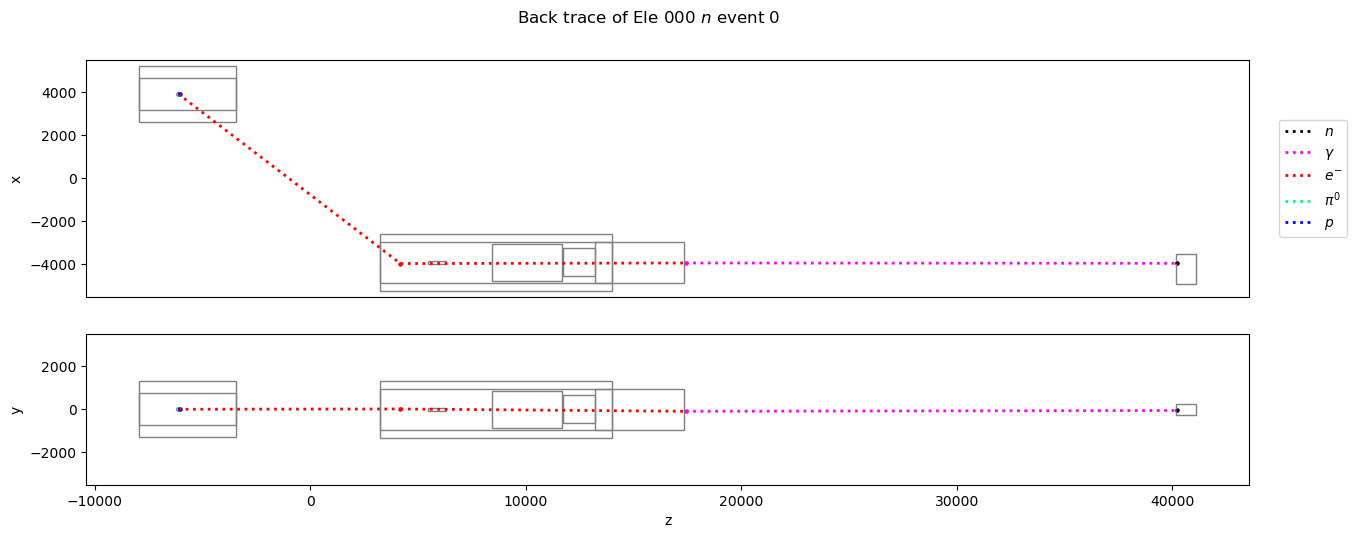

------------------------------------------------------------------------------


level_0                        30
tag                           Ele
fileno                          0
index                          30
time                   201.021446
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3882.410063
y                      -12.279014
z                         40185.4
startx               -3826.740234
starty                 -56.889068
startz               40224.833738
starttime              183.101181
E                      468.277514
weight                  41.157161
Name: 30, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,219,Ele,0,30,182.459412,183.101181,97,2112,-3831.245488,-58.595502,40229.693323,5.948122e+02
1,220,Ele,0,30,178.450043,182.459412,97,2112,-3832.725089,-13.885205,40231.485048,7.314903e+02
2,221,Ele,0,30,177.655701,178.450043,109,2112,-3825.702440,-17.080180,40224.945589,8.485097e+02
3,222,Ele,0,30,176.588806,176.655701,16,22,-3824.224521,-30.242296,40209.888310,1.451160e+04
4,223,Ele,0,30,55.885151,176.590546,56,11,-3868.638796,8.353716,4179.000000,6.289431e+04
5,224,Ele,0,30,3.760805,55.951866,13,11,3929.121202,0.430808,-6058.269764,8.382735e+04
6,225,Ele,0,30,3.753958,3.760805,14,22,3929.136694,0.030263,-6060.282952,1.361120e+05
7,226,Ele,0,30,3.753957,3.753958,101,111,3929.136664,0.030219,-6060.283026,7.588003e+04
8,227,Ele,0,30,3.744574,3.753957,56,2212,3929.815987,0.031345,-6057.569149,8.000000e+06


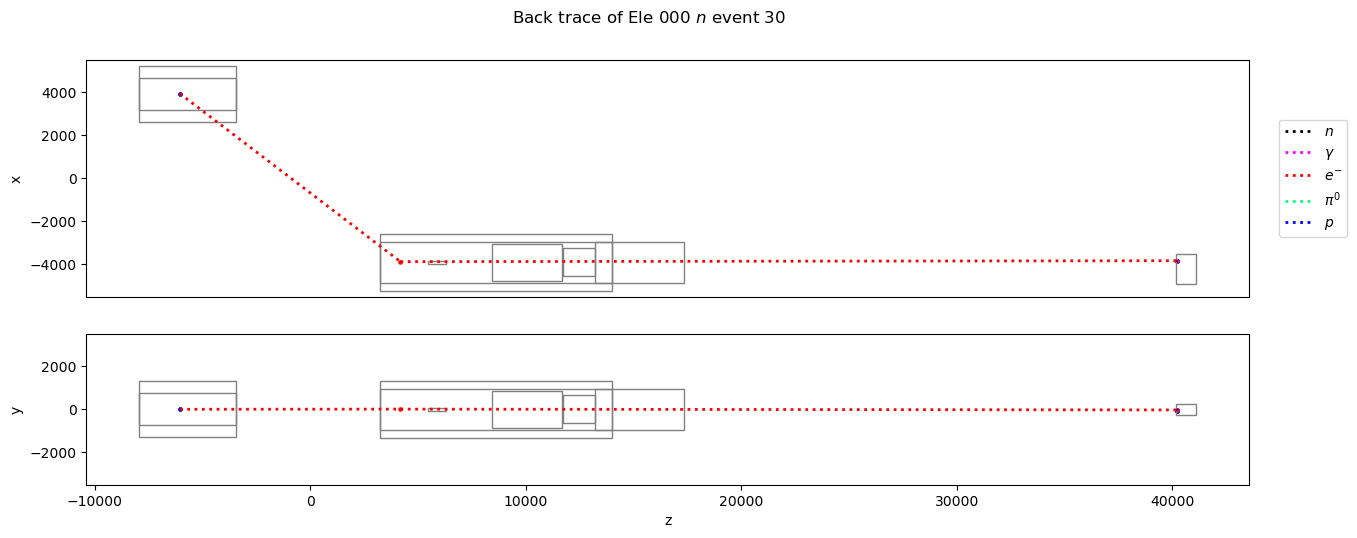

------------------------------------------------------------------------------


level_0                        60
tag                           Ele
fileno                          1
index                          23
time                   191.499197
virtualdetectorId             101
creationCode                  109
pdgId                        2112
x                    -3910.625845
y                      -77.920751
z                         40185.4
startx                -3951.78215
starty                 -28.408618
startz               40212.420299
starttime              184.175156
E                      475.436597
weight                  41.157161
Name: 60, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,431,Ele,1,23,183.157440,183.175156,16,22,-3952.608368,-29.358757,40207.259496,1.388762e+04
1,432,Ele,1,23,62.757351,183.160599,56,11,-3887.610495,10.752575,4179.000000,5.268007e+04
2,433,Ele,1,23,10.098610,62.824066,13,11,3910.263418,-0.212684,-6127.873843,1.663415e+05
3,434,Ele,1,23,10.079020,10.098610,14,22,3910.011931,-0.185538,-6133.741601,1.751211e+05
4,435,Ele,1,23,10.079020,10.079020,101,111,3910.011949,-0.185550,-6133.741662,1.387458e+05
5,436,Ele,1,23,9.815022,10.079020,56,2212,3929.352342,-0.440697,-6057.453550,8.000000e+06


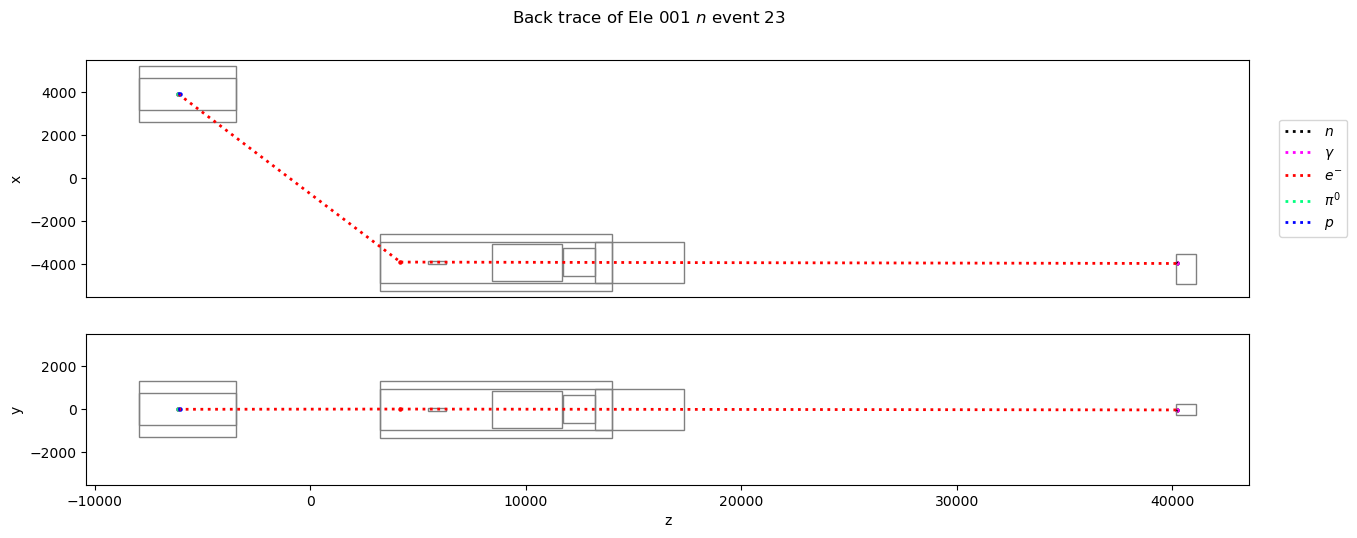

------------------------------------------------------------------------------


level_0                        90
tag                           Ele
fileno                          1
index                          53
time                   175.785545
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3937.060258
y                      -23.923068
z                         40185.4
startx               -3946.301755
starty                 -14.222485
startz               40209.525256
starttime              172.690643
E                      616.702386
weight                  41.157161
Name: 90, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,639,Ele,1,53,171.516922,172.690643,109,2112,-3951.712500,-21.049836,40210.988337,7.661983e+02
1,640,Ele,1,53,93.784843,170.516922,16,22,-4010.565671,42.567637,17207.453131,1.736374e+04
2,641,Ele,1,53,47.726379,94.077988,56,11,-3938.080904,-62.865406,4179.000000,4.588501e+04
3,642,Ele,1,53,-13.004634,47.793098,13,11,3911.412248,1.553396,-6130.740606,4.832942e+04
4,643,Ele,1,53,-13.015244,-13.004634,16,22,3912.832786,-0.057851,-6133.086817,6.057882e+04
5,644,Ele,1,53,-13.016141,-13.006111,13,-11,3912.951182,-0.192067,-6133.287282,8.307075e+04
6,645,Ele,1,53,-13.017559,-13.016141,14,22,3913.129172,-0.406552,-6133.608170,2.186573e+05
7,646,Ele,1,53,-13.017559,-13.017559,101,111,3913.129188,-0.406604,-6133.608226,1.668023e+05
8,647,Ele,1,53,-13.278599,-13.017559,56,2212,3931.562159,-0.702994,-6058.004519,8.000000e+06


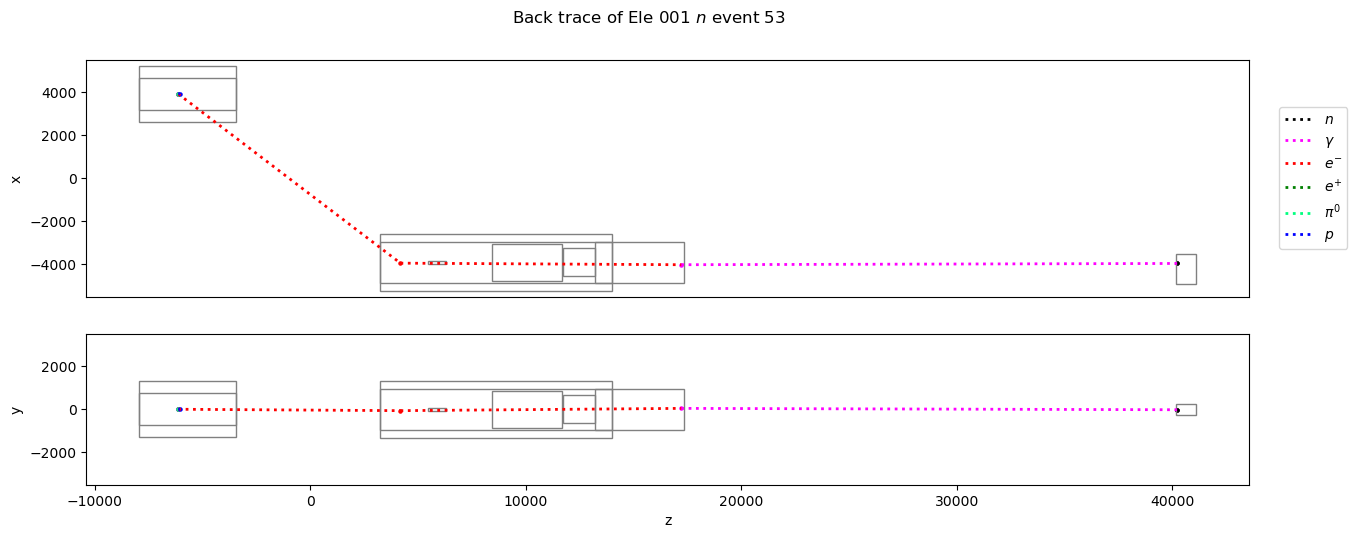

------------------------------------------------------------------------------


level_0                       120
tag                           Ele
fileno                          2
index                          26
time                   189.895606
virtualdetectorId             101
creationCode                  109
pdgId                        2112
x                    -3900.620527
y                      -76.425571
z                         40185.4
startx               -3889.816686
starty                 -65.733544
startz               40209.765414
starttime              188.027908
E                     1238.233313
weight                  41.157161
Name: 120, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,858,Ele,2,26,187.022400,187.027908,16,22,-3889.496834,-66.199525,40208.215679,1.344260e+04
1,859,Ele,2,26,64.198700,187.026627,56,11,-3902.463352,-2.183251,4179.000000,4.182291e+04
2,860,Ele,2,26,0.011455,64.265419,13,11,3896.775805,-3.110937,-6200.151284,4.897802e+04
3,861,Ele,2,26,-0.009112,0.011455,97,22,3892.564843,-2.063326,-6204.531434,7.447599e+04
4,862,Ele,2,26,-0.260064,-0.009112,101,2112,3911.176800,-2.695887,-6132.948380,4.200170e+06
5,863,Ele,2,26,-0.520555,-0.260064,56,2212,3930.112171,-2.034407,-6057.642996,8.000000e+06


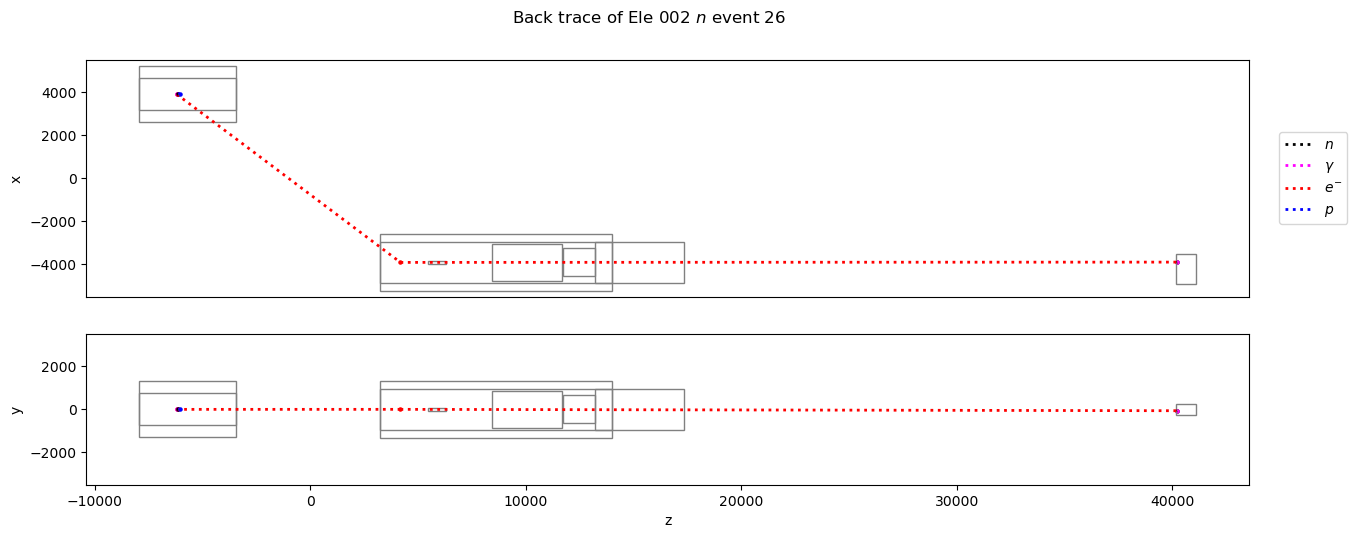

------------------------------------------------------------------------------


level_0                       150
tag                           Ele
fileno                          3
index                           8
time                   238.396841
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                     -3865.22298
y                       17.973663
z                         40185.4
startx               -3869.971345
starty                  14.787646
startz               40226.910594
starttime              236.039917
E                     1668.892025
weight                  41.157161
Name: 150, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,1076,Ele,3,8,232.492142,236.039917,97,2112,-3864.027486,83.184804,40208.168507,2.110388e+03
1,1077,Ele,3,8,232.406631,232.492142,109,2112,-3865.576327,82.458664,40208.638497,2.258409e+03
2,1078,Ele,3,8,231.404541,231.406631,16,22,-3865.483606,82.455299,40208.016298,1.433017e+04
3,1079,Ele,3,8,109.837311,231.422379,56,11,-3882.490127,-68.426454,4179.000000,6.586750e+04
4,1080,Ele,3,8,53.193893,109.904022,13,11,3890.165168,-0.722036,-6213.931629,1.410206e+05
5,1081,Ele,3,8,53.189426,53.193893,14,22,3890.779798,-0.555886,-6215.110350,1.729796e+05
6,1082,Ele,3,8,53.189426,53.189426,101,111,3890.779801,-0.555886,-6215.110358,7.120241e+04
7,1083,Ele,3,8,52.644932,53.189426,56,2212,3929.998093,-1.505917,-6057.614553,8.000000e+06


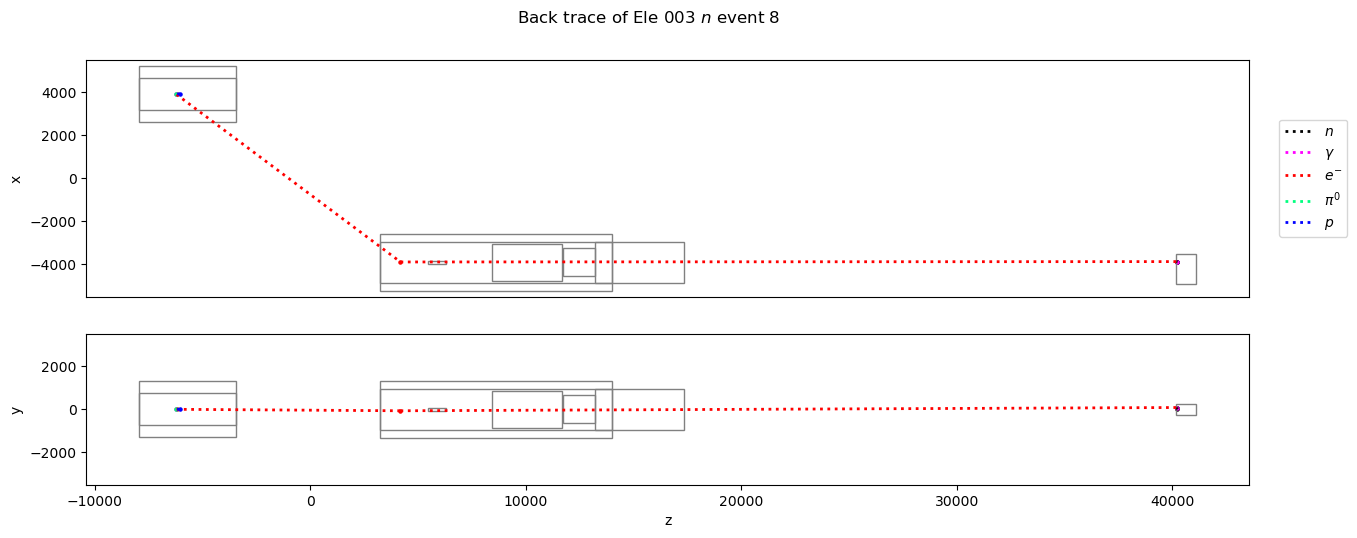

------------------------------------------------------------------------------


level_0                       180
tag                           Ele
fileno                          3
index                          38
time                   174.491778
virtualdetectorId             101
creationCode                  109
pdgId                        2112
x                    -3807.159349
y                       -7.222818
z                         40185.4
startx               -3807.254994
starty                 -32.996554
startz               40225.153221
starttime              168.766617
E                      440.940736
weight                  41.157161
Name: 180, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,1282,Ele,3,38,91.311897,167.766617,16,22,-3979.646994,-76.919627,17305.294088,1.338635e+04
1,1283,Ele,3,38,45.925751,134.083099,56,11,-3928.049774,3.287358,4179.000000,3.565539e+04
2,1284,Ele,3,38,-10.314955,45.992474,13,11,3912.394422,1.488529,-6124.651888,4.001842e+04
3,1285,Ele,3,38,-10.315594,-10.314955,14,22,3912.329004,1.417424,-6124.817141,1.205142e+05
4,1286,Ele,3,38,-10.315594,-10.315594,101,111,3912.329026,1.417391,-6124.817226,1.123507e+05
5,1287,Ele,3,38,-10.548661,-10.315594,56,2212,3929.273863,1.448905,-6057.433983,8.000000e+06


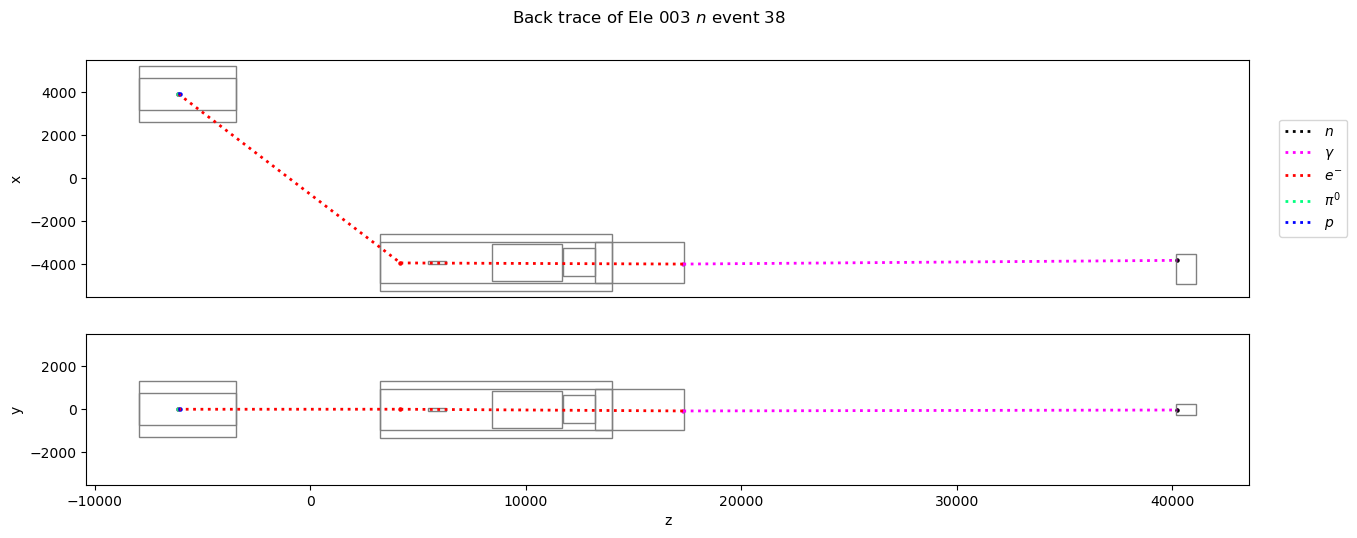

In [4]:
for ii in range(0, len(dfn_Ele), 30):
    print('------------------------------------------------------------------------------')
    dfn_ = dfn_Ele.iloc[ii]
    tag, fileno, index = dfn_['tag'], dfn_['fileno'], dfn_['index']
    dfg_ = df_genealogy.query("tag==@tag and fileno==@fileno and index==@index").reset_index()
    display(dfn_)
    display(dfg_)
    fig, ax_top, ax_side = plot_utils.draw_neutron_event_backtrace(df_neutron, df_genealogy, tag, fileno, index)
    plt.show()

source count
$\gamma$ :  197
$\pi^{-}$ :  4


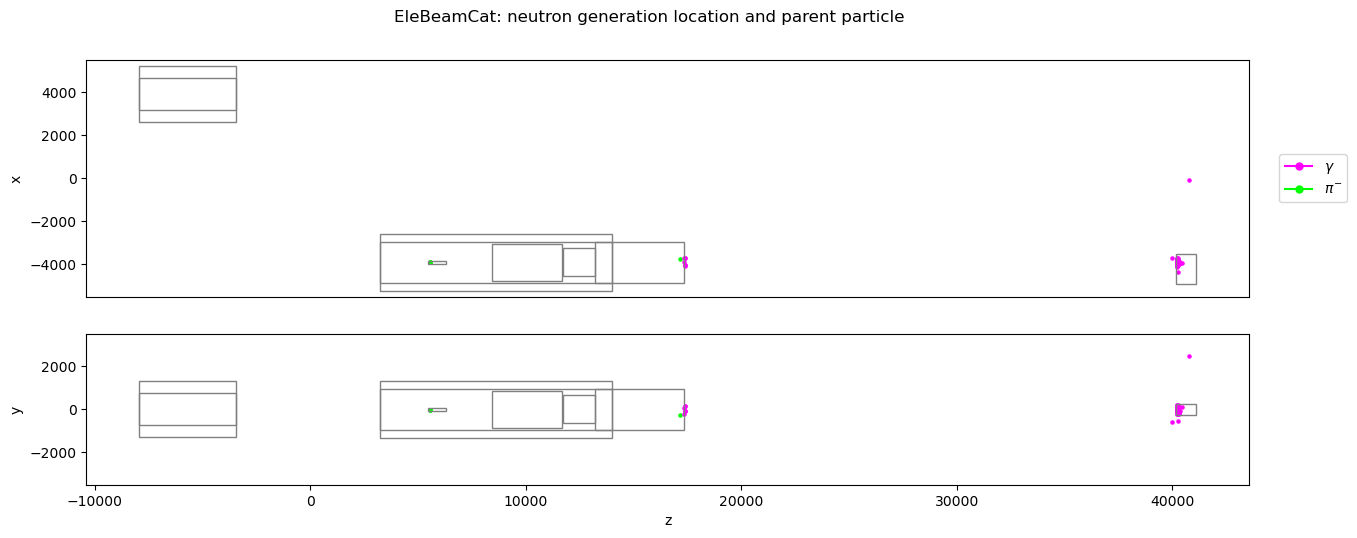

In [5]:
dfs_Ele, fig, ax_top, ax_side = plot_utils.draw_neutron_source_all(dfn_Ele, dfg_Ele, "EleBeamCat: neutron generation location and parent particle")

------------------------------------------------------------------------------


level_0                         201
tag                              Mu
fileno                            0
index                             0
time                 1301800.288347
virtualdetectorId               101
creationCode                     97
pdgId                          2112
x                      -3936.345302
y                         -80.14015
z                           40185.4
startx                 -3480.634497
starty                   752.892933
startz                 17133.554422
starttime               2864.839355
E                          0.000367
weight                     1.005488
Name: 0, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,1442,Mu,0,0,2856.556396,2864.839355,97,2112,-3535.354247,727.587595,17192.291823,9.703259e+02
1,1443,Mu,0,0,2855.174316,2856.556396,97,2112,-3545.839395,744.076345,17188.047780,1.096083e+03
2,1444,Mu,0,0,2854.141113,2855.174316,97,2112,-3553.725506,728.487587,17188.741993,1.500182e+03
3,1445,Mu,0,0,2824.389160,2854.141113,97,2112,-3853.028996,588.492731,16797.285962,1.980535e+03
4,1446,Mu,0,0,2802.053467,2824.389160,115,2112,-4181.013167,-205.666532,16010.216175,1.458207e+04
5,1447,Mu,0,0,77.575340,163.715027,56,13,-3952.676029,-84.906105,4179.000000,1.343686e+04
6,1448,Mu,0,0,10.884252,77.719917,14,13,2242.602176,33.509375,-324.393921,1.393044e+04
7,1449,Mu,0,0,-43.906342,10.884252,101,-211,3897.494577,0.437175,-6181.934286,2.546531e+04
8,1450,Mu,0,0,-44.337410,-43.906342,56,2212,3928.280528,-0.679806,-6057.186316,8.000000e+06


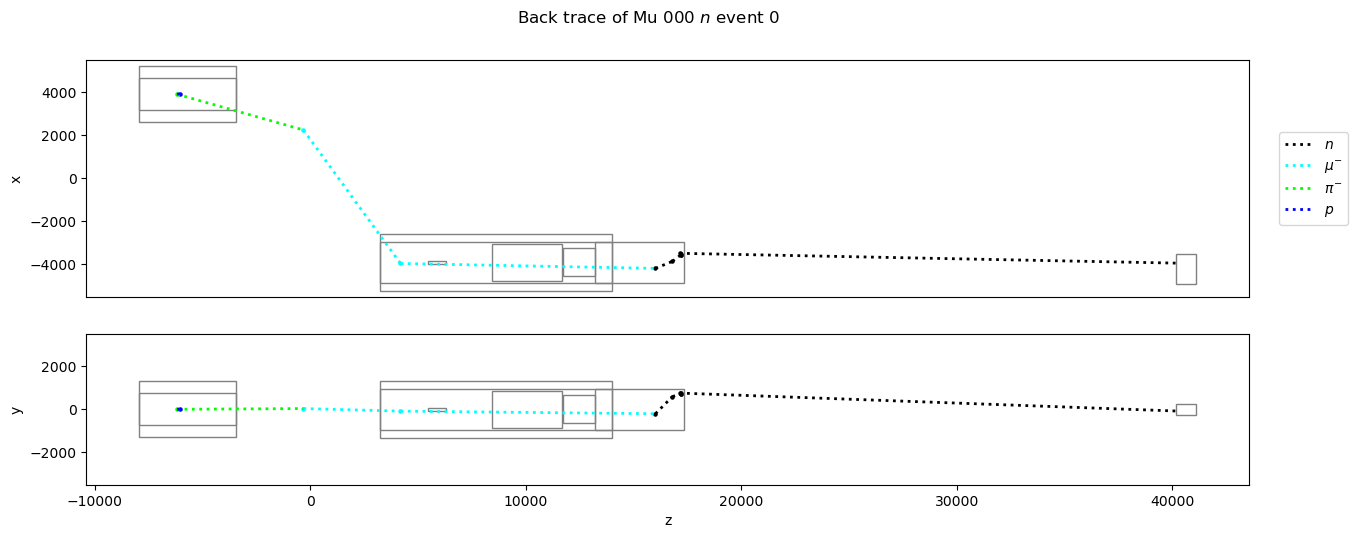

------------------------------------------------------------------------------


level_0                       301
tag                            Mu
fileno                          0
index                         100
time                  4492.441073
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3917.225457
y                       30.439317
z                         40185.4
startx               -3999.813998
starty                  -5.169778
startz               40235.318744
starttime             1315.104858
E                        0.091537
weight                   1.005488
Name: 100, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,2000,Mu,0,100,296.427673,1315.104858,115,2112,-3867.802087,20.565291,5826.530344,6.021256e+03
1,2001,Mu,0,100,237.305237,264.631348,56,13,-3828.072671,18.599631,4179.000000,5.159973e+03
2,2002,Mu,0,100,-19.822710,237.526443,14,13,3943.914030,46.323983,-5618.784909,7.703822e+03
3,2003,Mu,0,100,-30.655901,-19.822710,101,-211,3900.897361,1.767399,-6186.583376,2.033475e+04
4,2004,Mu,0,100,-31.099316,-30.655901,56,2212,3932.005173,1.185802,-6058.114975,8.000000e+06


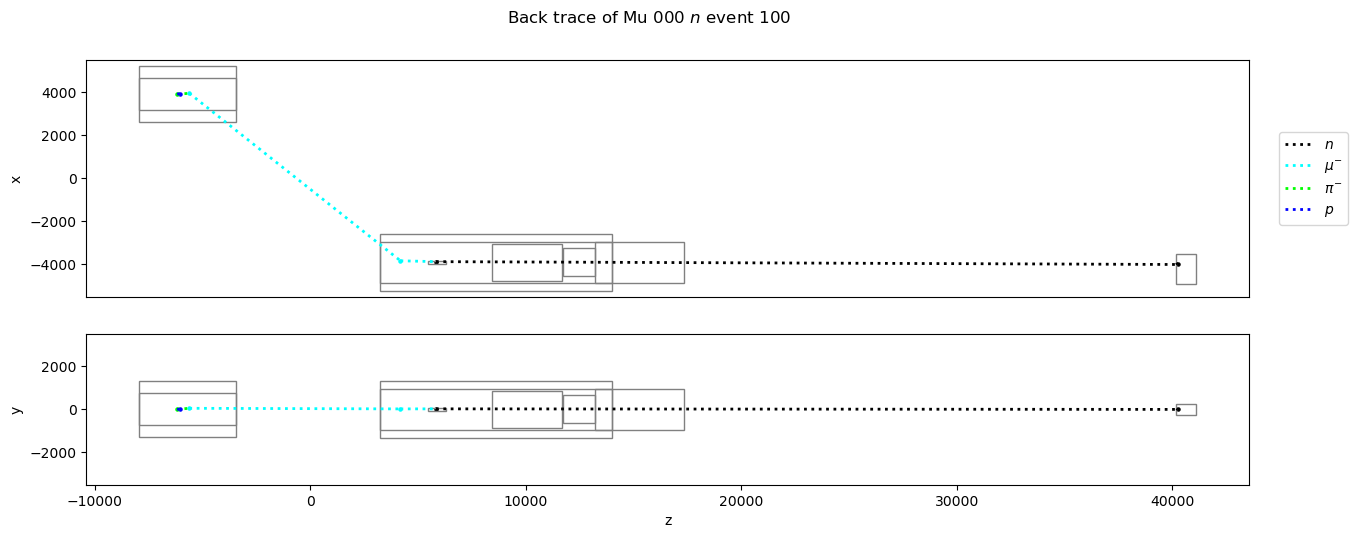

------------------------------------------------------------------------------


level_0                       401
tag                            Mu
fileno                          0
index                         200
time                 10348.051212
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3928.022983
y                       75.256746
z                         40185.4
startx               -4431.955632
starty                -372.870712
startz                5633.797312
starttime             2129.943359
E                       95.236165
weight                   1.005488
Name: 200, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,2534,Mu,0,200,2101.422363,2129.943359,115,2112,-3925.775698,-32.447213,5515.457067,5.700121e+03
1,2535,Mu,0,200,284.076599,308.520691,56,13,-3887.558288,-0.970542,4179.000000,2.653055e+03
2,2536,Mu,0,200,104.111092,284.379883,14,13,3037.019044,-4.330292,-848.877656,4.337310e+03
3,2537,Mu,0,200,43.352684,104.111092,101,-211,3882.423449,0.383305,-6248.936811,5.375367e+04
4,2538,Mu,0,200,42.691254,43.352684,56,2212,3930.112762,0.358422,-6057.643144,8.000000e+06


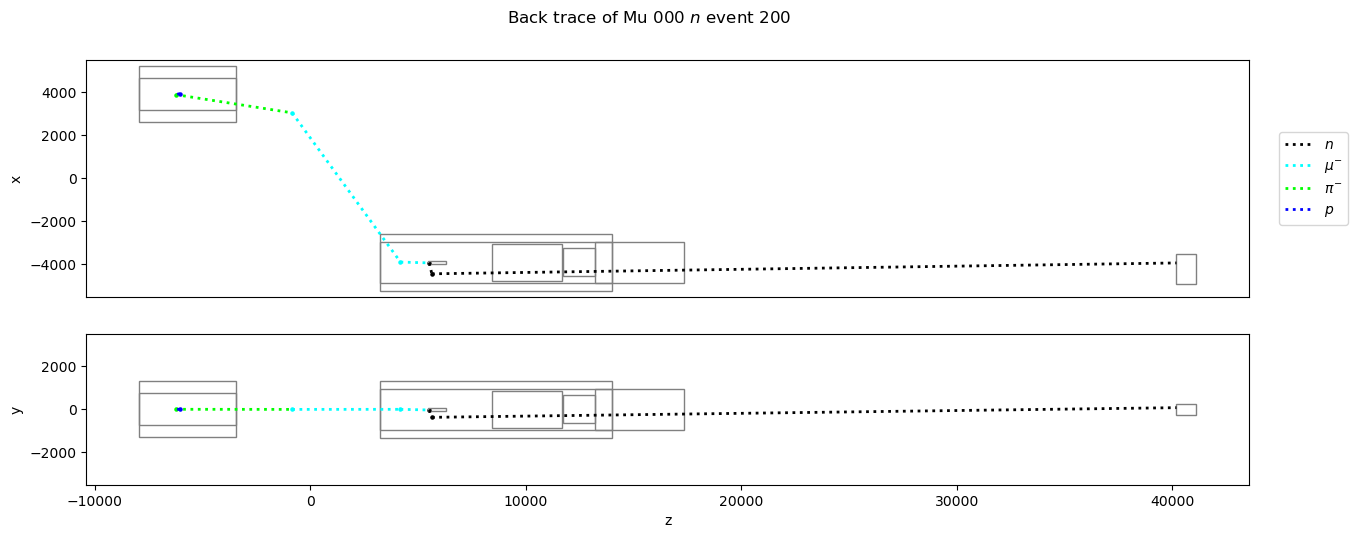

------------------------------------------------------------------------------


level_0                      501
tag                           Mu
fileno                         0
index                        300
time                 5765.283264
virtualdetectorId            101
creationCode                 115
pdgId                       2112
x                    -3914.36534
y                      16.426311
z                       40185.38
startx              -3938.334258
starty                 -8.615921
startz               6137.664697
starttime            1154.566406
E                     330.037519
weight                  1.005488
Name: 300, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,3062,Mu,0,300,94.486572,112.786964,56,13,-3929.321596,34.217387,4179.000000,1.008373e+04
1,3063,Mu,0,300,-15.200056,94.649986,14,13,3892.450175,26.516364,-3825.877099,1.077777e+04
2,3064,Mu,0,300,-35.386211,-15.200056,101,-211,3899.757983,-0.136840,-6181.152372,4.374260e+04
3,3065,Mu,0,300,-35.812870,-35.386211,56,2212,3930.018569,-0.187455,-6057.619659,8.000000e+06


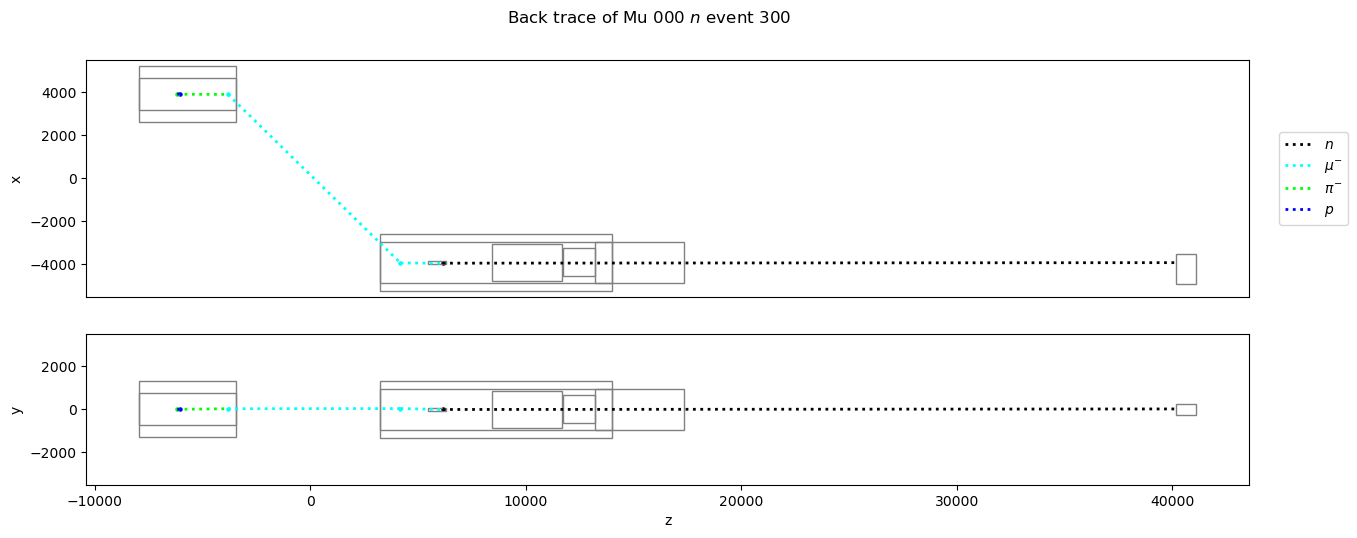

------------------------------------------------------------------------------


level_0                       601
tag                            Mu
fileno                          0
index                         400
time                  1555.251821
virtualdetectorId             101
creationCode                  115
pdgId                        2112
x                    -3982.251935
y                       -25.86488
z                        40185.38
startx               -3891.148339
starty                   87.69696
startz               17305.369474
starttime             1215.746216
E                    24680.046314
weight                   1.005488
Name: 400, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,3568,Mu,0,400,92.567986,179.329208,56,13,-3909.538842,-4.716604,4179.000000,1.685584e+04
1,3569,Mu,0,400,3.668417,92.699776,14,13,3892.170920,7.602751,-3968.964866,1.729089e+04
2,3570,Mu,0,400,-12.427226,3.668417,101,-211,3906.132689,0.898457,-6154.572450,4.000001e+04
3,3571,Mu,0,400,-12.762182,-12.427226,56,2212,3930.725861,0.413507,-6057.796006,8.000000e+06


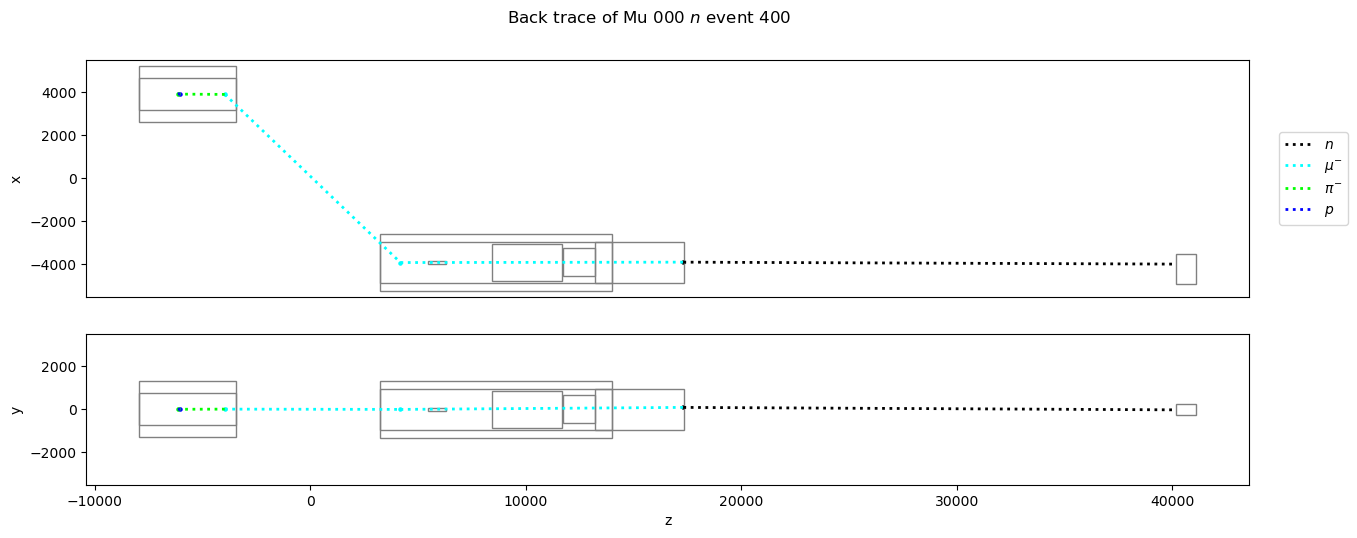

------------------------------------------------------------------------------


level_0                         701
tag                              Mu
fileno                            0
index                           500
time                 5442778.762392
virtualdetectorId               101
creationCode                     97
pdgId                          2112
x                      -3917.794125
y                        -16.492418
z                          40185.38
startx                 -3890.026618
starty                   129.870304
startz                 17393.599866
starttime               1215.094849
E                          0.000083
weight                     1.005488
Name: 500, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,4089,Mu,0,500,1209.367920,1215.094849,115,2112,-3759.697087,10.956274,17156.143063,1.556225e+04
1,4090,Mu,0,500,140.019943,413.072357,56,13,-3870.898937,-13.371889,4179.000000,1.023529e+04
2,4091,Mu,0,500,25.565502,140.182297,14,13,3922.177952,0.860350,-4749.300302,1.130009e+04
3,4092,Mu,0,500,9.251905,25.565502,101,-211,3926.877638,0.279632,-6070.529449,2.936990e+04
4,4093,Mu,0,500,9.207341,9.251905,56,2212,3930.072175,0.267335,-6057.633024,8.000000e+06


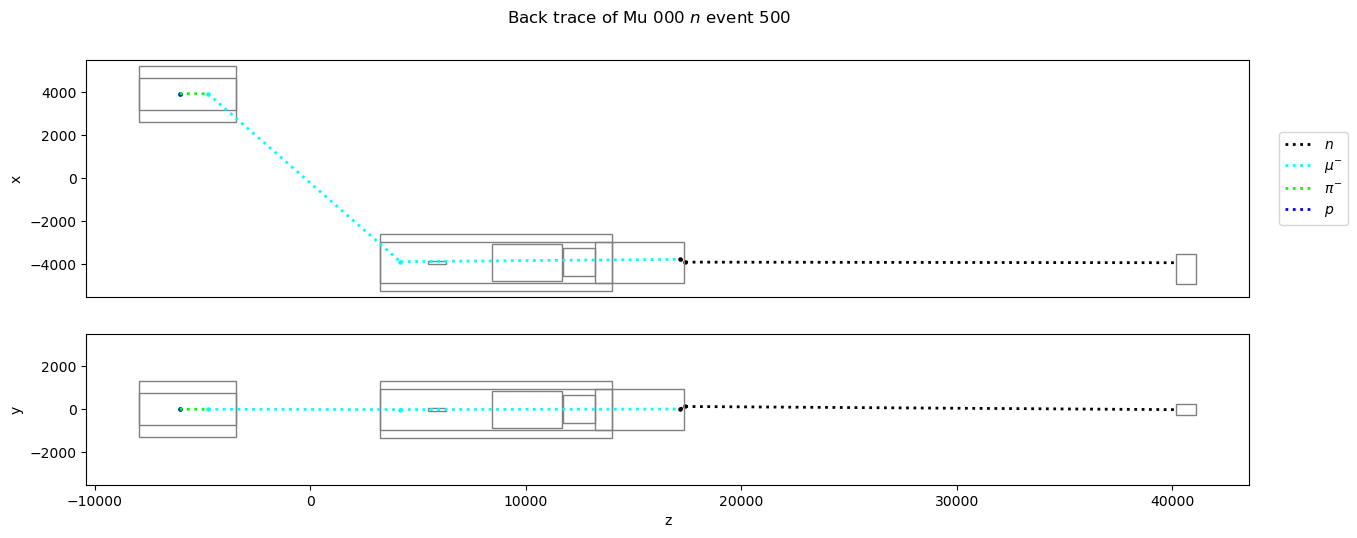

------------------------------------------------------------------------------


level_0                       801
tag                            Mu
fileno                          0
index                         600
time                 22399.136031
virtualdetectorId             101
creationCode                  115
pdgId                        2112
x                    -3942.518538
y                      -39.370508
z                         40185.4
startx               -3930.907673
starty                   9.737494
startz                5737.716365
starttime              359.998413
E                       12.529596
weight                   1.005488
Name: 600, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,4603,Mu,0,600,236.318756,255.515198,56,13,-3963.585599,17.050435,4179.000000,5.240299e+03
1,4604,Mu,0,600,56.220558,236.538376,14,13,3893.886509,10.921771,-5887.029848,7.224254e+03
2,4605,Mu,0,600,51.409939,56.220558,14,-211,3902.604724,5.241526,-6175.222668,2.758708e+04
3,4606,Mu,0,600,51.135452,51.409939,14,3122,3906.724880,0.052340,-6161.809334,1.890853e+04
4,4607,Mu,0,600,51.135452,51.135452,101,3212,3906.724880,0.052340,-6161.809334,2.007447e+04
5,4608,Mu,0,600,50.777424,51.135452,56,2212,3932.235620,-0.099519,-6058.172431,8.000000e+06


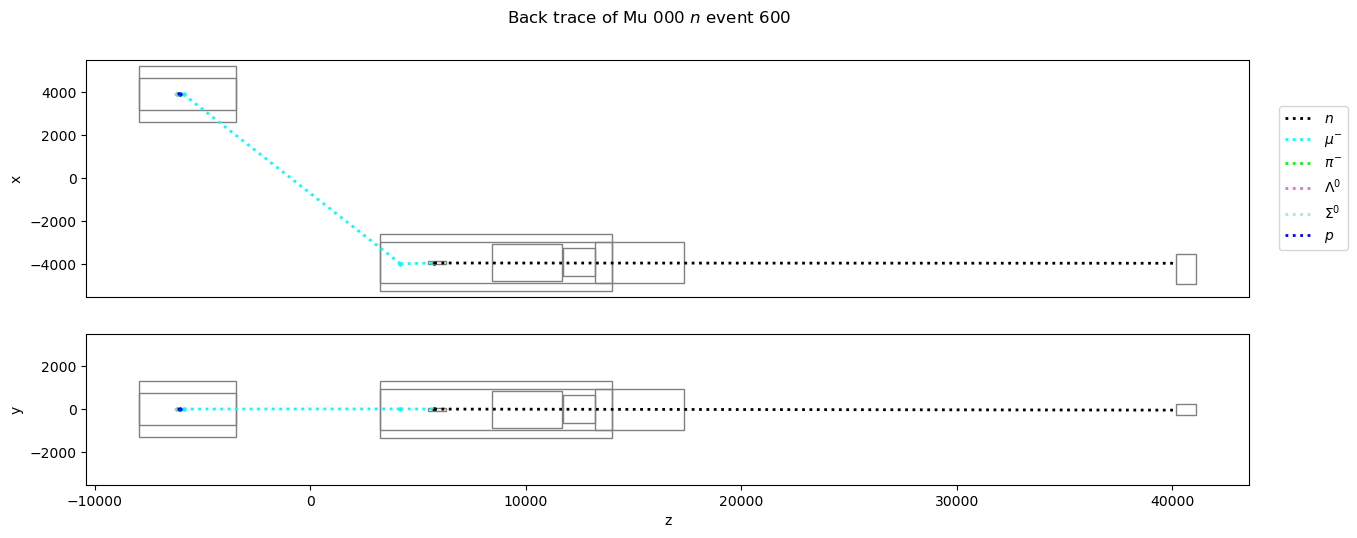

------------------------------------------------------------------------------


level_0                       901
tag                            Mu
fileno                          0
index                         700
time                   888.427837
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3836.309932
y                      -68.929895
z                         40185.4
startx               -3857.792804
starty                 -70.650002
startz               40245.766935
starttime              885.210632
E                     2081.833031
weight                   1.005488
Name: 700, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,5144,Mu,0,700,882.526306,885.210632,97,2112,-3888.497862,6.673419,40247.949413,6.271002e+03
1,5145,Mu,0,700,342.702240,882.526306,115,2112,-3871.416986,-35.832521,6226.514338,2.147593e+04
2,5146,Mu,0,700,158.686539,180.286713,56,13,-3848.589922,-21.084971,4179.000000,8.820138e+03
3,5147,Mu,0,700,47.087254,158.859863,14,13,3938.231849,-10.999545,-3089.939055,9.471643e+03
4,5148,Mu,0,700,29.271179,47.087254,14,-211,3913.064041,-6.680243,-6168.486625,3.606093e+04
5,5149,Mu,0,700,29.059900,29.271179,101,3122,3902.216453,1.027084,-6173.946000,2.992828e+04
6,5150,Mu,0,700,28.658703,29.059900,56,2212,3931.141695,0.364243,-6057.899685,8.000000e+06


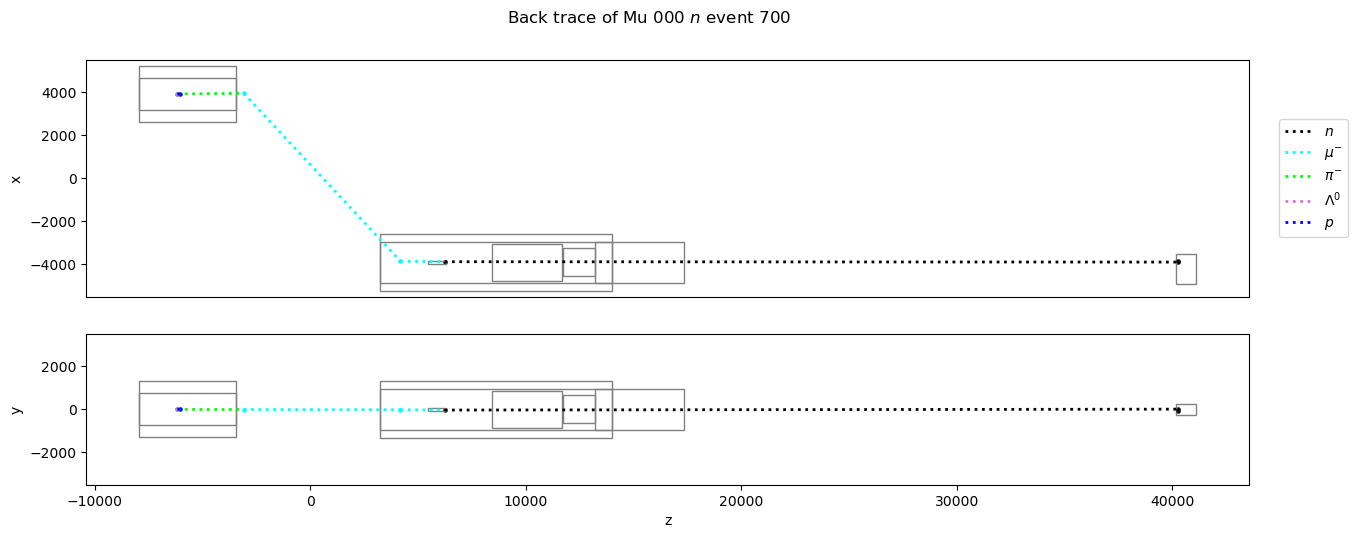

------------------------------------------------------------------------------


level_0                       1001
tag                             Mu
fileno                           0
index                          800
time                 107073.982867
virtualdetectorId              101
creationCode                   115
pdgId                         2112
x                     -3882.403457
y                       -78.309583
z                         40185.38
startx                -3873.321052
starty                   -1.887516
startz                 6159.882391
starttime              3649.133789
E                         0.678008
weight                    1.005488
Name: 800, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,5687,Mu,0,800,190.343231,212.111755,56,13,-3832.022300,10.577999,4179.000000,9.084981e+03
1,5688,Mu,0,800,32.571522,190.514297,14,13,3898.666244,19.149278,-5306.271182,1.046067e+04
2,5689,Mu,0,800,12.315929,32.571522,101,-211,3882.913898,-0.982149,-6257.910323,4.843241e+04
3,5690,Mu,0,800,11.625684,12.315929,56,2212,3931.843223,-1.680905,-6058.074596,8.000000e+06


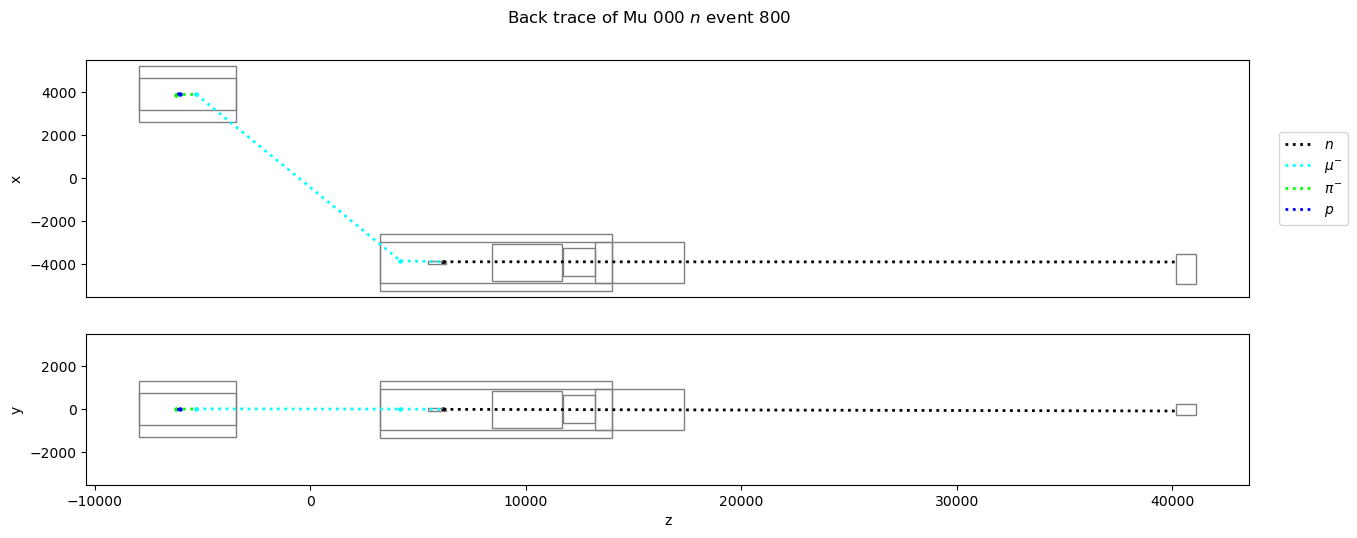

------------------------------------------------------------------------------


level_0                      1101
tag                            Mu
fileno                          0
index                         900
time                  1357.476738
virtualdetectorId             101
creationCode                  115
pdgId                        2112
x                      -3938.3887
y                       84.811397
z                        40185.38
startx               -3869.445098
starty                 -56.857993
startz                5759.836248
starttime              766.335083
E                    18245.346709
weight                   1.005488
Name: 900, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,6211,Mu,0,900,213.769592,242.515182,56,13,-3875.309307,-5.758722,4179.000000,5.070198e+03
1,6212,Mu,0,900,-29.397825,213.992599,14,13,3925.425808,-5.071757,-5930.881687,7.026978e+03
2,6213,Mu,0,900,-36.513035,-29.397825,101,-211,3930.057066,-2.645458,-6058.348509,1.034298e+04
3,6214,Mu,0,900,-36.515373,-36.513035,56,2212,3930.226268,-2.645771,-6057.671444,8.000000e+06


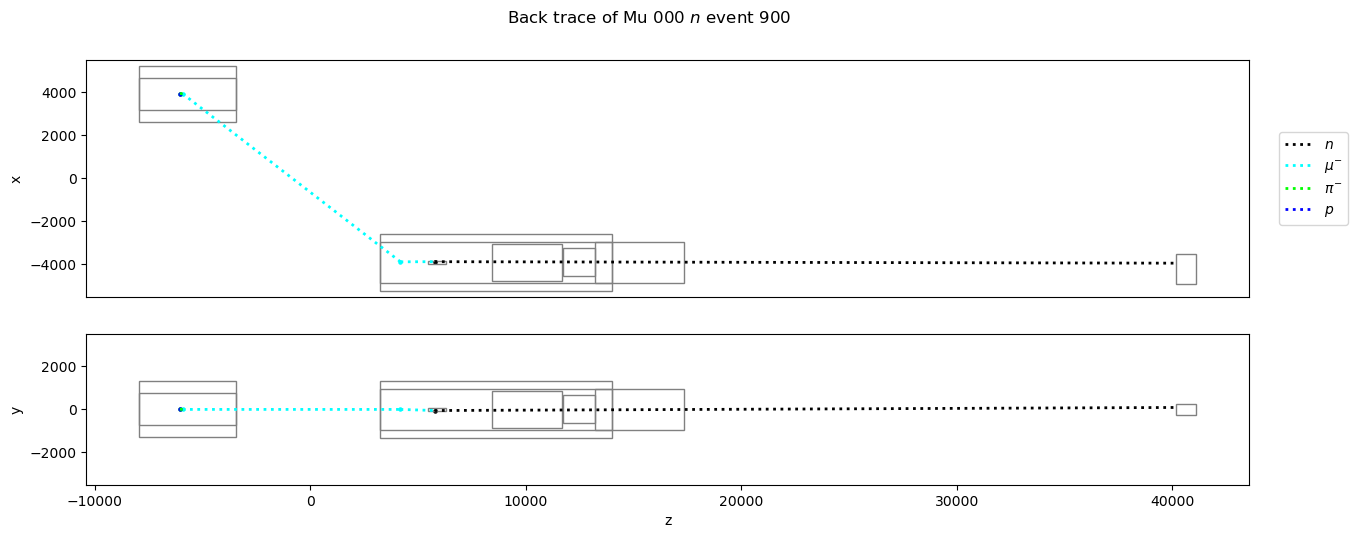

------------------------------------------------------------------------------


level_0                      1201
tag                            Mu
fileno                          0
index                        1000
time                  1339.117907
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                     -3950.07144
y                       67.015396
z                         40185.4
startx               -3978.859338
starty                  84.247656
startz               40238.935032
starttime             1328.929199
E                      376.427013
weight                   1.005488
Name: 1000, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,6749,Mu,0,1000,1301.175415,1328.929199,97,2112,-3895.132402,44.374612,40302.851348,6.227200e+02
1,6750,Mu,0,1000,824.018188,1301.175415,115,2112,-3869.069462,-8.203161,5537.680248,2.904438e+04
2,6751,Mu,0,1000,168.986755,189.015839,56,13,-3864.174224,0.254073,4179.000000,2.949929e+03
3,6752,Mu,0,1000,-41.077534,169.274948,14,13,3925.092713,-9.826687,-6083.565524,5.024487e+03
4,6753,Mu,0,1000,-41.252083,-41.077534,101,-211,3923.728750,-1.369078,-6082.452949,2.060268e+04
5,6754,Mu,0,1000,-41.338009,-41.252083,56,2212,3929.947442,-1.358212,-6057.601925,8.000000e+06


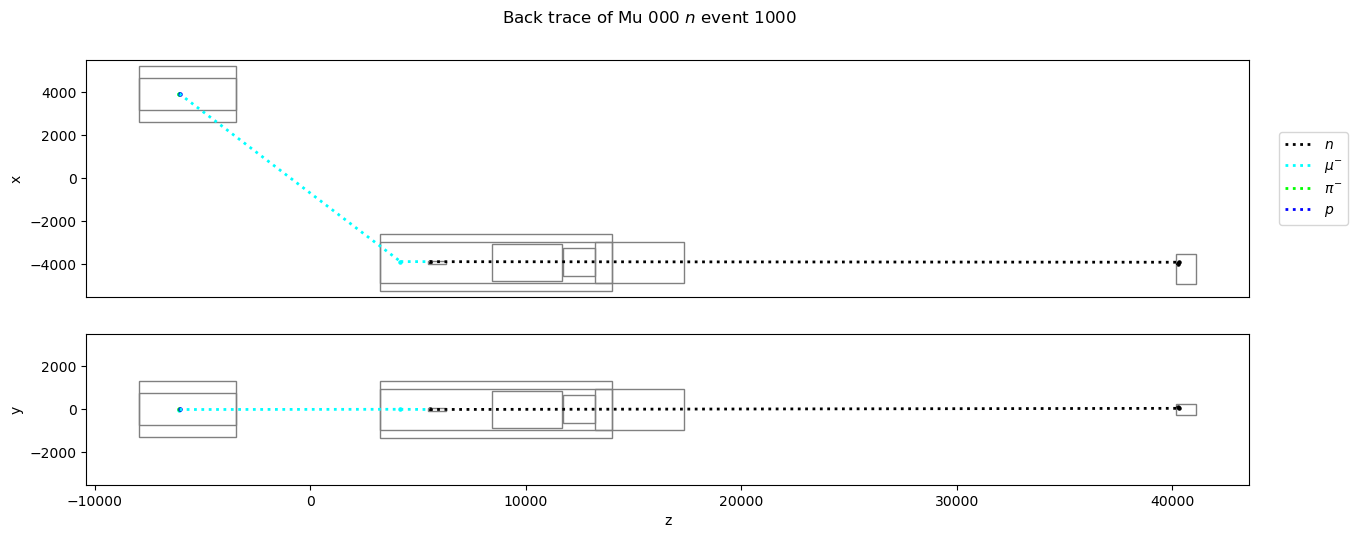

------------------------------------------------------------------------------


level_0                         1301
tag                               Mu
fileno                             1
index                             36
time                 14188848.958766
virtualdetectorId                101
creationCode                     115
pdgId                           2112
x                        -3934.06767
y                         -34.799071
z                           40185.38
startx                  -4001.863906
starty                     80.973432
startz                  17403.459379
starttime                1263.561157
E                           0.000013
weight                      1.005488
Name: 1100, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,7281,Mu,1,36,167.628906,251.403442,56,13,-3953.988081,-8.957847,4179.000000,2.199531e+04
1,7282,Mu,1,36,73.859322,167.747787,14,13,3919.103068,-4.831983,-5271.086907,2.264423e+04
2,7283,Mu,1,36,65.771233,73.859322,101,-211,3916.980650,-0.234089,-6109.134511,2.727654e+04
3,7284,Mu,1,36,65.592979,65.771233,56,2212,3929.690984,-0.318250,-6057.537983,8.000000e+06


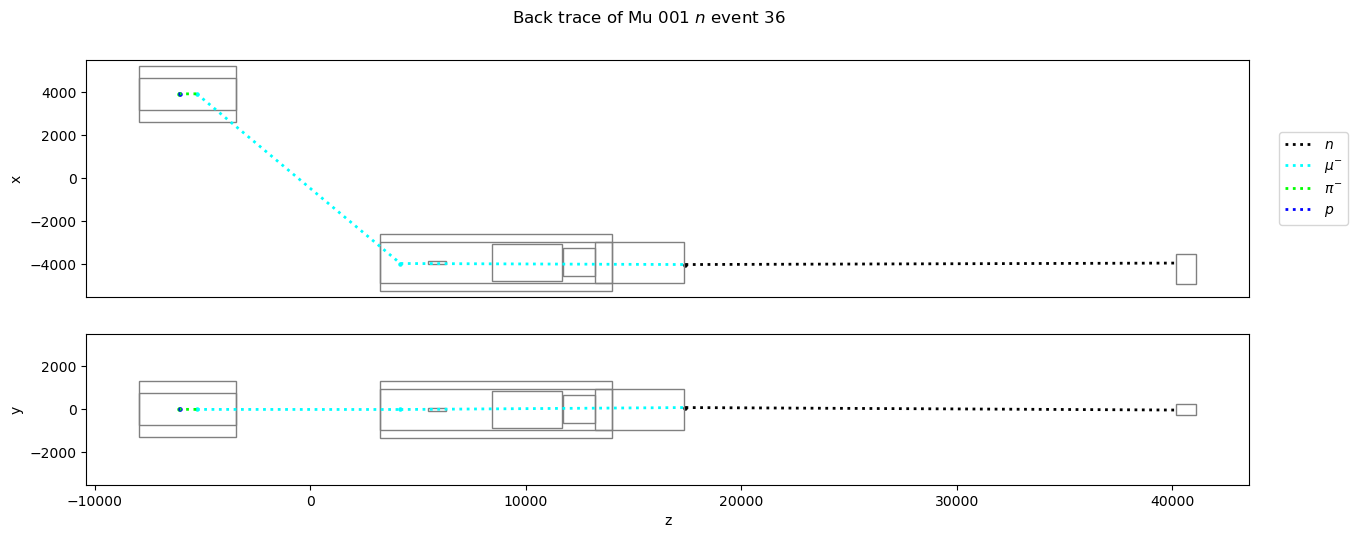

------------------------------------------------------------------------------


level_0                      1401
tag                            Mu
fileno                          1
index                         136
time                  1657.348269
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3845.354601
y                       66.407402
z                         40185.4
startx               -3851.475191
starty                  60.753182
startz               40213.367038
starttime             1655.312866
E                     1076.254172
weight                   1.005488
Name: 1200, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,7789,Mu,1,136,1655.092285,1655.312866,97,2112,-3852.592107,60.535120,40216.487510,1.187673e+03
1,7790,Mu,1,136,1654.333374,1655.092285,97,2112,-3865.067522,61.788512,40225.660594,2.198333e+03
2,7791,Mu,1,136,575.956604,1654.333374,115,2112,-3934.293552,-15.385297,5604.331021,5.434521e+03
3,7792,Mu,1,136,277.318726,298.774628,56,13,-3927.505040,26.208395,4179.000000,3.932149e+03
4,7793,Mu,1,136,62.763248,277.570007,14,13,3881.093829,18.784845,-5040.114822,6.229166e+03
5,7794,Mu,1,136,53.781181,62.763248,101,-211,3902.069391,0.056738,-6160.194549,2.834654e+04
6,7795,Mu,1,136,53.424610,53.781181,56,2212,3928.449365,-0.445914,-6057.228412,8.000000e+06


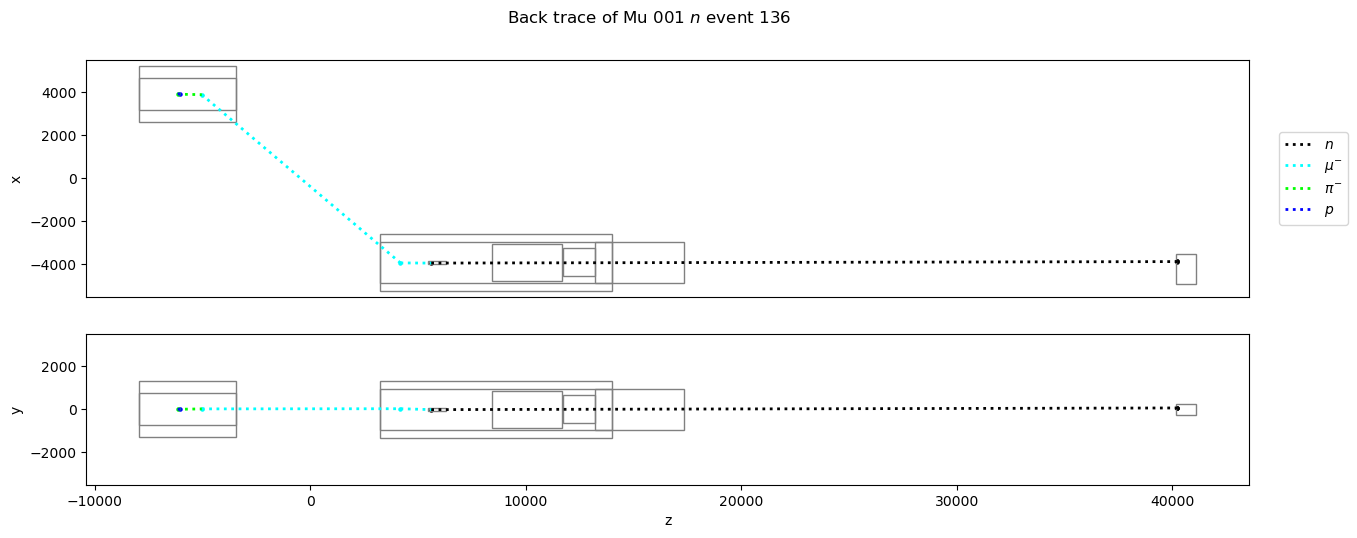

------------------------------------------------------------------------------


level_0                      1501
tag                            Mu
fileno                          1
index                         236
time                  2763.494114
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3840.127006
y                        0.926517
z                         40185.4
startx               -3841.975146
starty                  -5.510791
startz               40208.454358
starttime             2757.771729
E                       92.017871
weight                   1.005488
Name: 1300, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,8323,Mu,1,236,955.519409,2757.771729,97,2112,-3854.015427,1067.905397,6400.338075,2.546976e+03
1,8324,Mu,1,236,912.079590,955.519409,115,2112,-3899.492027,24.889928,5515.486476,5.231325e+03
2,8325,Mu,1,236,183.638351,207.991745,56,13,-3868.099972,-8.327810,4179.000000,2.714440e+03
3,8326,Mu,1,236,-50.653736,183.938309,14,13,3927.169233,1.457213,-5570.992795,5.074212e+03
4,8327,Mu,1,236,-56.119041,-50.653736,101,-211,3925.441421,-0.887714,-6073.988682,2.913596e+04
5,8328,Mu,1,236,-56.176029,-56.119041,56,2212,3929.478808,-0.904620,-6057.485081,8.000000e+06


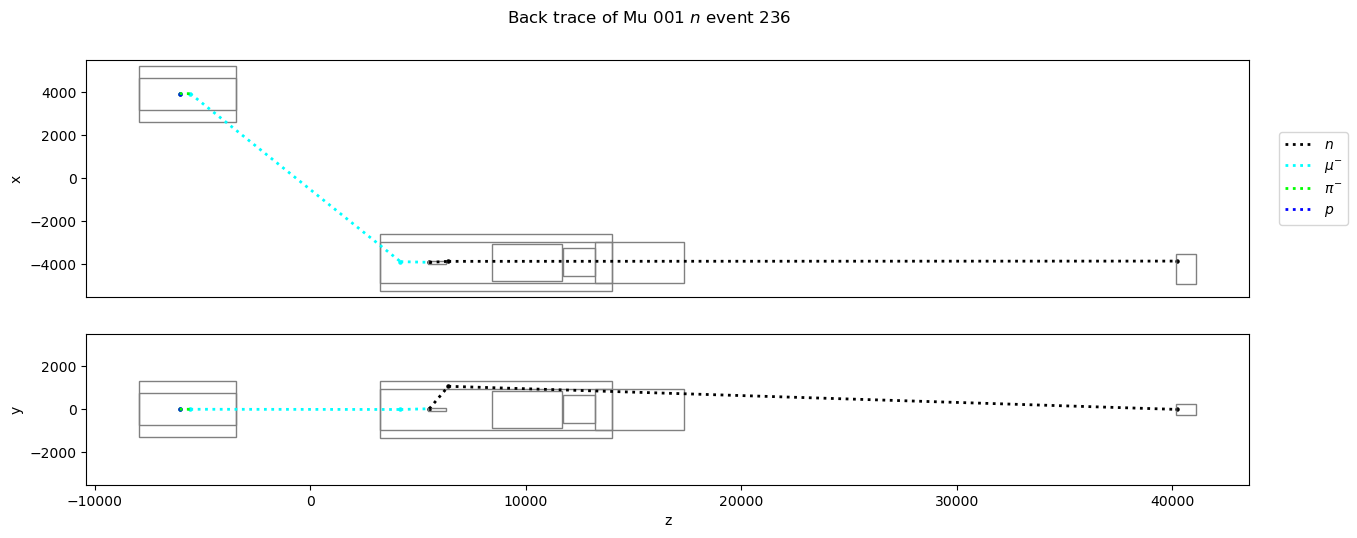

------------------------------------------------------------------------------


level_0                      1601
tag                            Mu
fileno                          1
index                         336
time                 10008.243213
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                     -3988.96562
y                      -40.102582
z                        40185.38
startx               -4039.414213
starty                -950.472196
startz                4934.555958
starttime             2680.315918
E                      163.221163
weight                   1.005488
Name: 1400, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,8888,Mu,1,336,2623.991455,2680.315918,97,2112,-4184.971228,-912.350662,4788.829006,6.693592e+02
1,8889,Mu,1,336,2562.608398,2623.991455,115,2112,-3840.302495,26.235163,5515.489062,2.126612e+03
2,8890,Mu,1,336,278.058838,299.598907,56,13,-3853.688012,30.180316,4179.000000,2.825296e+03
3,8891,Mu,1,336,49.128616,278.353088,14,13,3913.693271,25.285223,-5720.876410,5.272663e+03
4,8892,Mu,1,336,37.403816,49.128616,101,-211,3917.578033,-0.202897,-6115.310988,2.780614e+04
5,8893,Mu,1,336,37.205952,37.403816,56,2212,3931.903514,-0.390802,-6058.089628,8.000000e+06


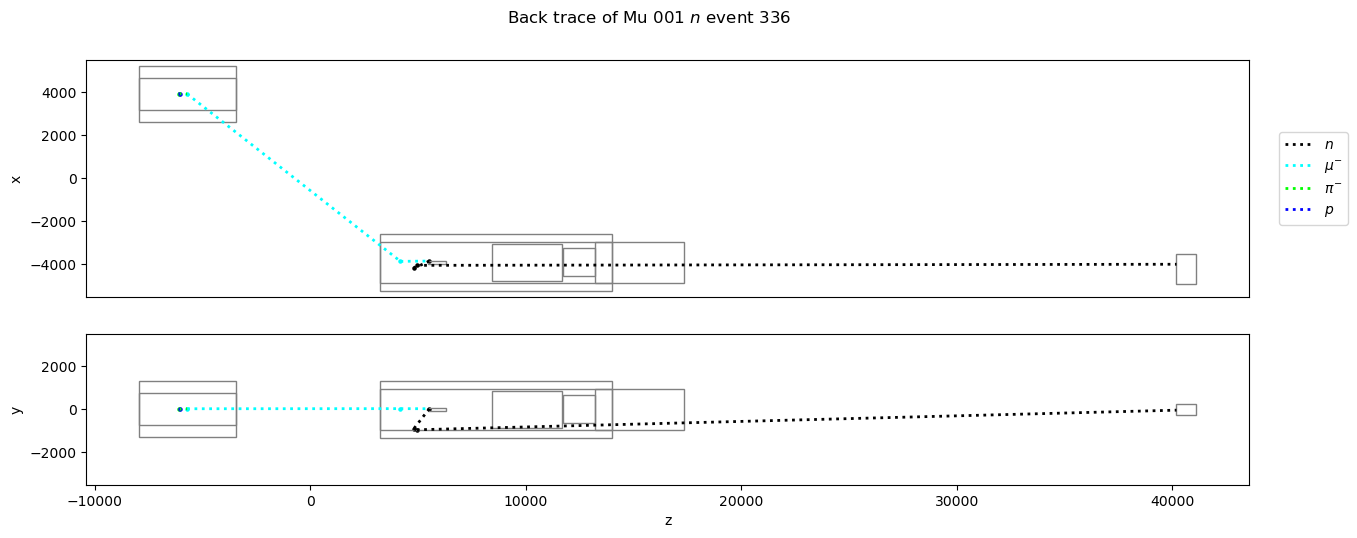

------------------------------------------------------------------------------


level_0                     1701
tag                           Mu
fileno                         1
index                        436
time                 1563.736642
virtualdetectorId            101
creationCode                 115
pdgId                       2112
x                   -3868.657155
y                      32.274187
z                       40185.38
startx              -3945.609569
starty                 16.825409
startz               5582.101223
starttime             475.817596
E                    5333.161131
weight                  1.005488
Name: 1500, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,9432,Mu,1,436,257.596710,280.061707,56,13,-3957.926240,23.639240,4179.000000,4.054910e+03
1,9433,Mu,1,436,24.091225,257.844391,14,13,3859.567916,-7.125775,-5607.704657,6.587298e+03
2,9434,Mu,1,436,13.426094,24.091225,101,-211,3915.469260,0.348558,-6121.530211,3.246531e+04
3,9435,Mu,1,436,13.206277,13.426094,56,2212,3931.361964,0.544994,-6057.954605,8.000000e+06


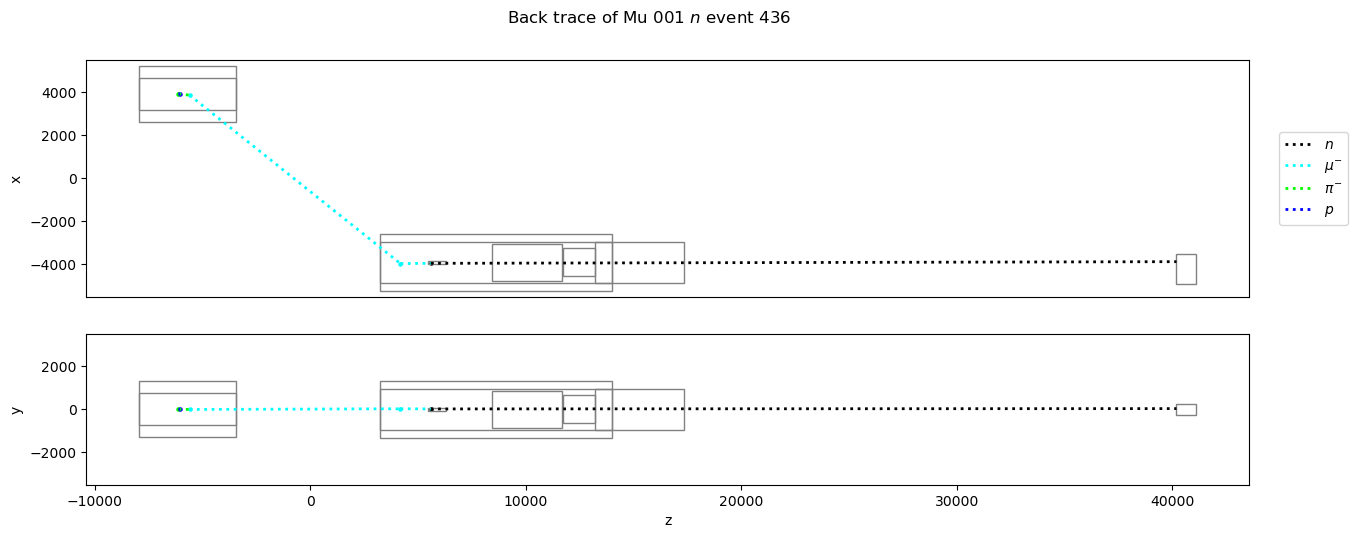

------------------------------------------------------------------------------


level_0                      1801
tag                            Mu
fileno                          1
index                         536
time                  3096.300686
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                     -3991.84351
y                       36.617642
z                         40185.4
startx               -3993.681936
starty                  19.907636
startz               40230.004538
starttime             3086.105957
E                      249.144452
weight                   1.005488
Name: 1600, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,9965,Mu,1,536,2465.469238,3086.105957,115,2112,-3941.945784,27.580249,5493.211172,1.681511e+04
1,9966,Mu,1,536,337.161072,370.441986,56,13,-3903.285547,42.986156,4179.000000,1.982174e+03
2,9967,Mu,1,536,-0.758831,337.510315,14,13,3854.678135,45.548576,-4964.525259,5.595879e+03
3,9968,Mu,1,536,-10.656337,-0.758831,101,-211,3931.738423,0.776724,-6058.816201,2.546531e+04
4,9969,Mu,1,536,-10.658835,-10.656337,56,2212,3931.918948,0.776350,-6058.093476,8.000000e+06


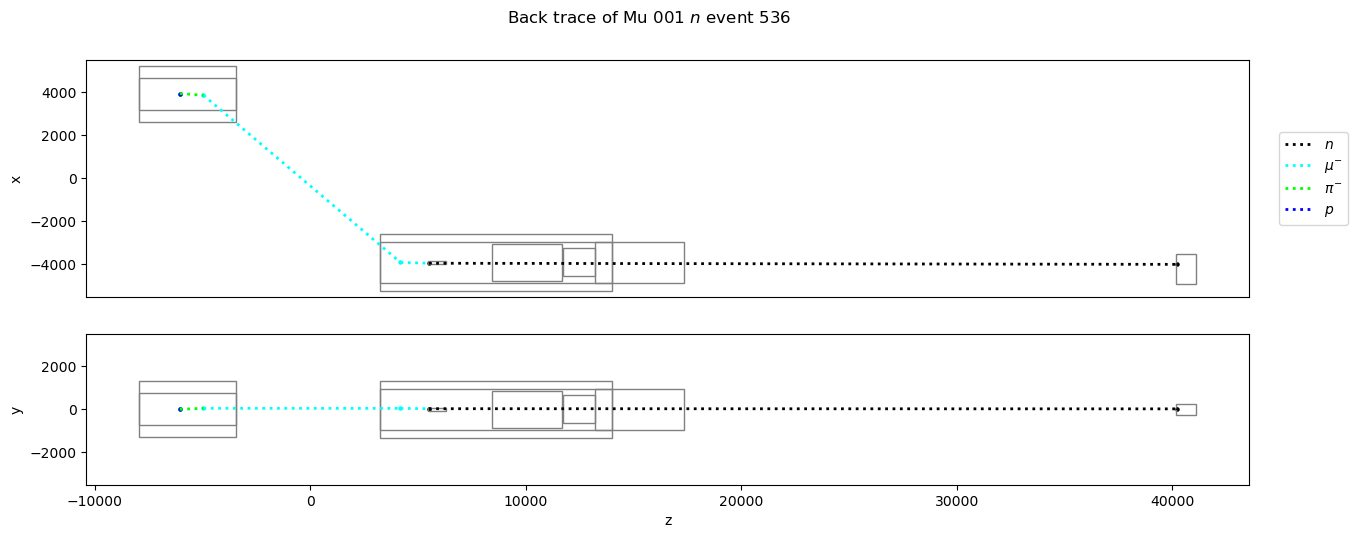

------------------------------------------------------------------------------


level_0                       1901
tag                             Mu
fileno                           1
index                          636
time                 395198.641169
virtualdetectorId              101
creationCode                    97
pdgId                         2112
x                     -3906.187372
y                        77.840227
z                         40185.38
startx                -4045.154848
starty                  861.470438
startz                17293.076467
starttime              1990.343262
E                         0.019871
weight                    1.005488
Name: 1700, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,10487,Mu,1,636,1932.157104,1990.343262,97,2112,-4197.764493,345.070223,16841.299298,1.175151e+03
1,10488,Mu,1,636,1917.631714,1932.157104,115,2112,-3888.682139,-319.162358,16892.774514,1.373214e+04
2,10489,Mu,1,636,163.839828,341.268951,56,13,-3813.552828,-46.362063,4179.000000,8.221220e+03
3,10490,Mu,1,636,-8.789054,164.018646,14,13,3939.259982,-68.940303,-5501.319236,9.262386e+03
4,10491,Mu,1,636,-25.714407,-8.789054,101,-211,3924.487112,-0.734341,-6082.061543,2.937262e+04
5,10492,Mu,1,636,-25.798447,-25.714407,56,2212,3930.515160,-0.770554,-6057.743473,8.000000e+06


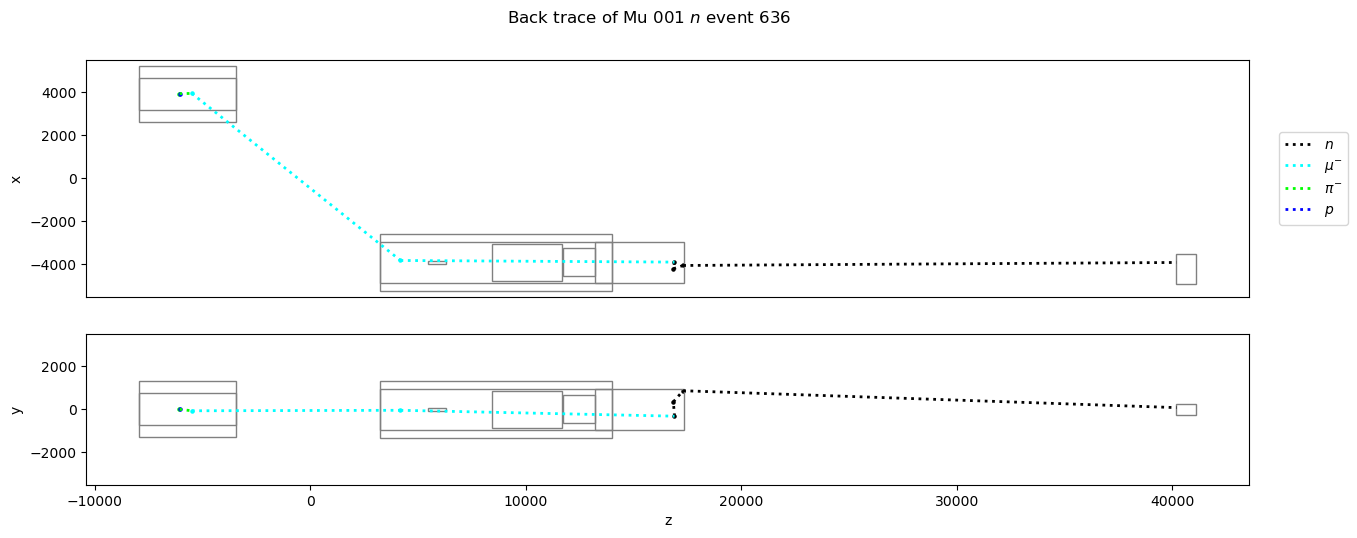

------------------------------------------------------------------------------


level_0                     2001
tag                           Mu
fileno                         1
index                        736
time                 98685.09759
virtualdetectorId            101
creationCode                 115
pdgId                       2112
x                   -3900.388199
y                      67.719626
z                       40185.38
startx              -3852.113293
starty                -53.256368
startz               5848.796089
starttime             629.703308
E                       0.092351
weight                  1.005488
Name: 1800, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,11022,Mu,1,736,222.029221,241.886749,56,13,-3855.385786,-42.539103,4179.000000,5.663686e+03
1,11023,Mu,1,736,66.835854,222.241058,14,13,3977.254705,-8.921651,-3762.119871,6.537127e+03
2,11024,Mu,1,736,47.230309,66.835854,101,-211,3901.544796,-1.024278,-6176.232591,6.437809e+04
3,11025,Mu,1,736,46.821114,47.230309,56,2212,3931.772728,-0.815933,-6058.057020,8.000000e+06


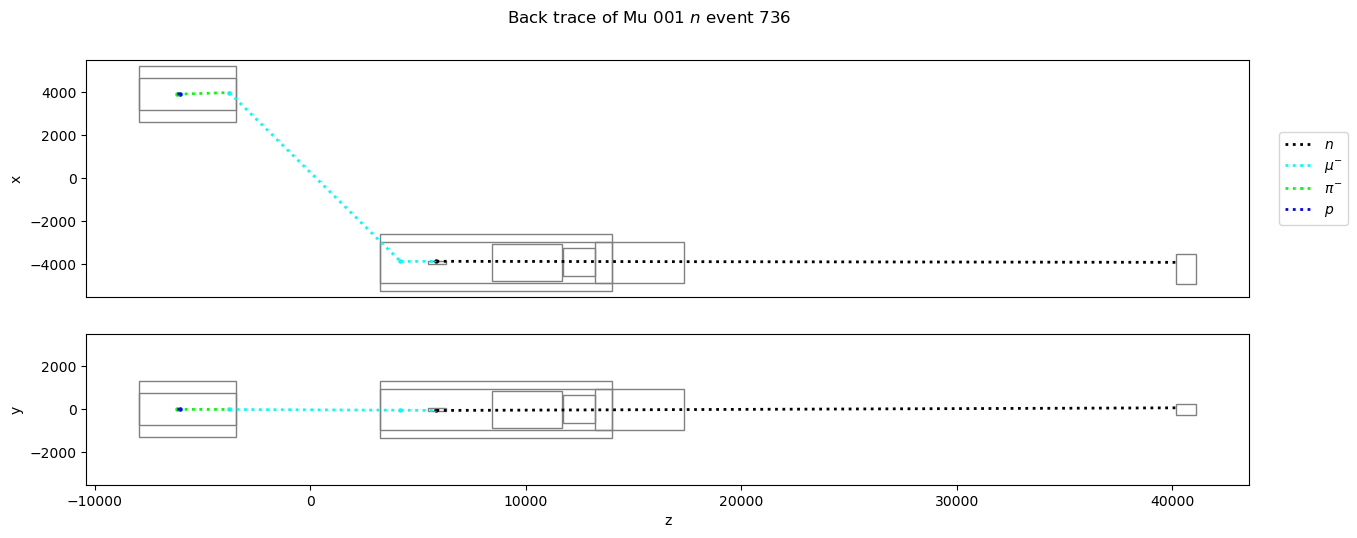

------------------------------------------------------------------------------


level_0                      2101
tag                            Mu
fileno                          1
index                         836
time                   2209.81285
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3993.278605
y                       27.051225
z                         40185.4
startx               -4055.307446
starty                   74.42396
startz               40225.534958
starttime              2200.91333
E                      602.504945
weight                   1.005488
Name: 1900, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,11557,Mu,1,836,429.985443,2200.913330,115,2112,-3882.334931,-58.636215,5871.005059,1.990694e+03
1,11558,Mu,1,836,273.724854,298.659790,56,13,-3937.558538,-58.333278,4179.000000,7.224959e+03
2,11559,Mu,1,836,19.993818,273.914337,14,13,3932.762073,-6.196268,-5881.688225,9.630463e+03
3,11560,Mu,1,836,15.407753,19.993818,101,-211,3922.937728,0.264872,-6088.189925,3.333397e+04
4,11561,Mu,1,836,15.302505,15.407753,56,2212,3930.720578,0.052290,-6057.794689,8.000000e+06


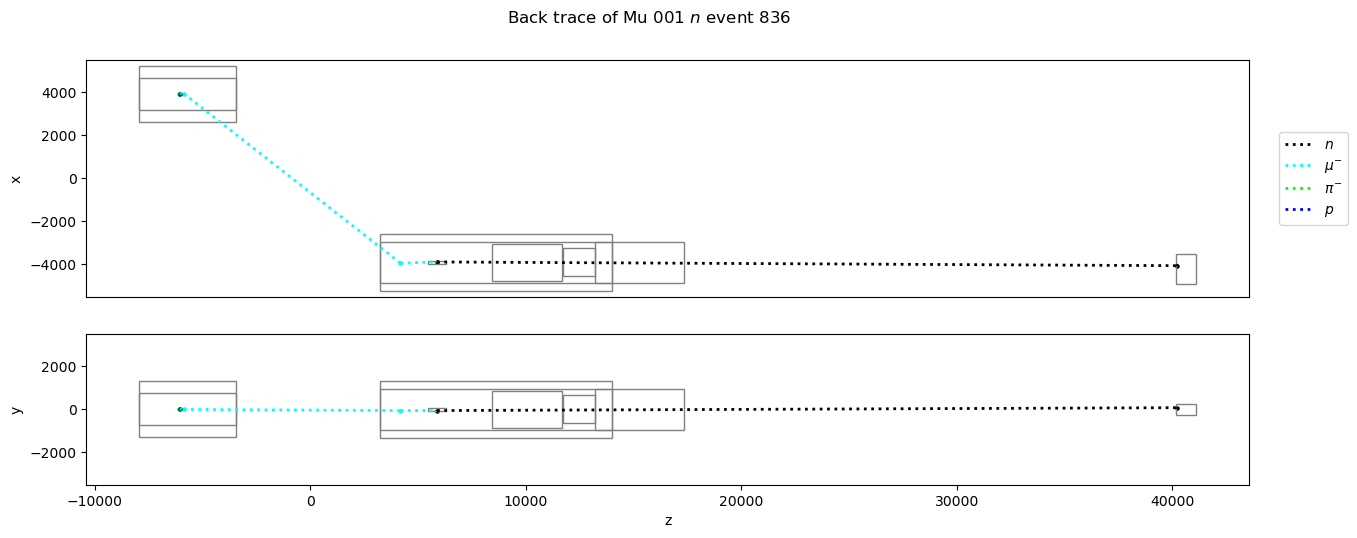

------------------------------------------------------------------------------


level_0                        2201
tag                              Mu
fileno                            1
index                           936
time                 1491512.208565
virtualdetectorId               101
creationCode                    115
pdgId                          2112
x                      -3836.218965
y                         12.401609
z                          40185.38
startx                 -3895.160102
starty                   -30.912607
startz                   5759.89856
starttime                397.917236
E                          0.004067
weight                     1.005488
Name: 2000, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,12073,Mu,1,936,254.925186,280.727600,56,13,-3874.449254,-5.134484,4179.000000,5.515348e+03
1,12074,Mu,1,936,-42.384155,255.139648,14,13,3925.347920,-14.496432,-5762.954136,7.370904e+03
2,12075,Mu,1,936,-55.567989,-42.384155,97,-211,3919.585306,2.831380,-6125.203927,3.154702e+04
3,12076,Mu,1,936,-55.788845,-55.567989,101,2112,3930.224098,1.737179,-6061.131492,3.916061e+06
4,12077,Mu,1,936,-55.790089,-55.788845,101,2212,3930.297712,1.727679,-6060.768598,7.860843e+06
5,12078,Mu,1,936,-55.800110,-55.790089,56,2212,3931.024488,1.727997,-6057.870462,8.000000e+06


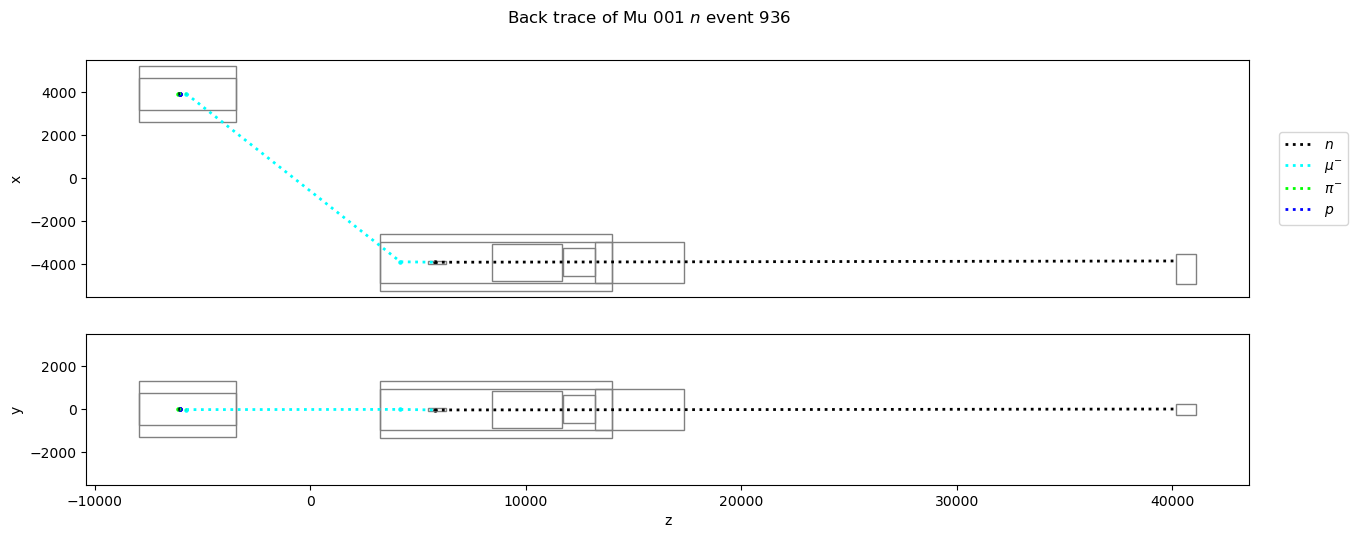

------------------------------------------------------------------------------


level_0                      2301
tag                            Mu
fileno                          1
index                        1036
time                  1518.657357
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3882.968313
y                       56.125824
z                         40185.4
startx               -3875.414516
starty                 -30.380886
startz               40232.091586
starttime             1473.169067
E                       93.861093
weight                   1.005488
Name: 2100, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,12568,Mu,1,1036,1470.140625,1473.169067,97,2112,-3888.832297,-33.854157,40213.423264,3.082658e+02
1,12569,Mu,1,1036,1468.877686,1470.140625,97,2112,-3895.467070,-25.976979,40217.871445,4.126937e+02
2,12570,Mu,1,1036,751.239441,1468.877686,115,2112,-3904.638205,37.094811,5493.185989,1.248277e+04
3,12571,Mu,1,1036,460.207092,499.092316,56,13,-3909.149122,26.200990,4179.000000,2.071106e+03
4,12572,Mu,1,1036,92.051292,460.548920,14,13,3929.543947,-4.245845,-4256.019155,6.189074e+03
5,12573,Mu,1,1036,55.049717,92.051292,101,-211,3918.297725,-3.048113,-6105.485779,7.408425e+03
6,12574,Mu,1,1036,54.884415,55.049717,56,2212,3930.038584,-3.038338,-6057.624649,8.000000e+06


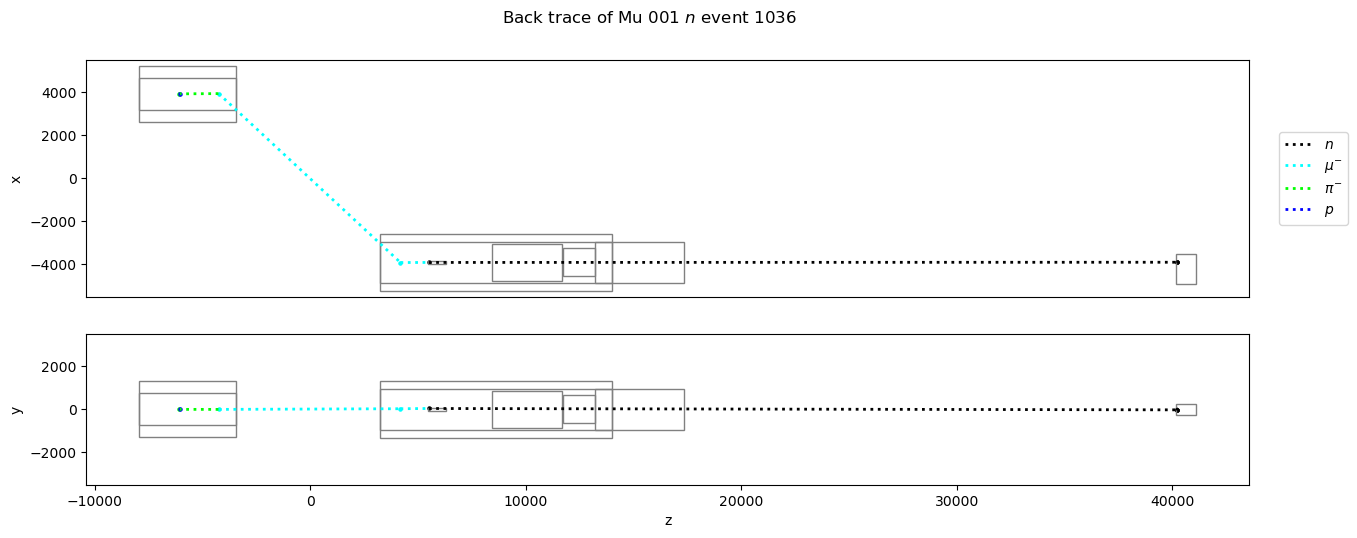

------------------------------------------------------------------------------


level_0                     2401
tag                           Mu
fileno                         2
index                          1
time                 6546.140127
virtualdetectorId            101
creationCode                  97
pdgId                       2112
x                   -3959.613534
y                      -0.829485
z                        40185.4
startx              -4745.462502
starty                480.477488
startz               6339.898639
starttime            1076.807861
E                     111.767903
weight                  1.005488
Name: 2200, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,13105,Mu,2,1,1035.184814,1076.807861,115,2112,-3967.523405,-10.829070,5537.701703,6.415126e+03
1,13106,Mu,2,1,443.010071,483.505310,56,13,-4010.444210,-7.982525,4179.000000,1.555672e+03
2,13107,Mu,2,1,5.555734,443.403107,14,13,3800.640845,-27.057888,-6296.865310,1.520435e+04
3,13108,Mu,2,1,0.985379,5.555734,101,-211,3918.563926,0.114672,-6100.137836,4.643787e+04
4,13109,Mu,2,1,0.837702,0.985379,56,2212,3929.271666,0.157109,-6057.433435,8.000000e+06


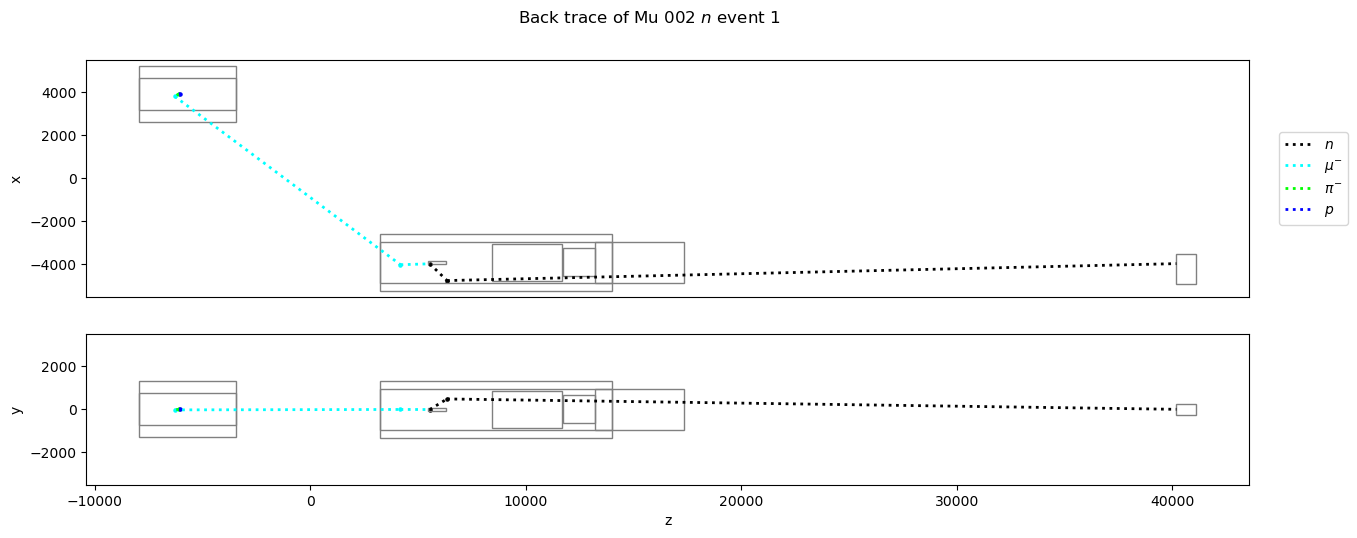

------------------------------------------------------------------------------


level_0                      2501
tag                            Mu
fileno                          2
index                         101
time                  1037.542816
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                     -3860.66428
y                      -37.990519
z                         40185.4
startx               -3897.728759
starty                  -44.09782
startz               40249.273215
starttime             1012.533325
E                      109.063775
weight                   1.005488
Name: 2300, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,13647,Mu,2,101,1003.568970,1012.533325,97,2112,-3897.737867,-28.174467,40226.318840,2.293420e+02
1,13648,Mu,2,101,999.361511,1003.568970,97,2112,-3924.520871,-26.848886,40219.783212,2.840660e+02
2,13649,Mu,2,101,614.469543,999.361511,115,2112,-3878.522927,-283.905604,17166.946189,1.995246e+04
3,13650,Mu,2,101,130.579147,226.545578,56,13,-3872.826821,-10.229198,4179.000000,1.728817e+04
4,13651,Mu,2,101,105.326637,130.709610,14,13,-2762.447524,59.710908,676.105483,1.728817e+04
5,13652,Mu,2,101,-1.815012,105.326637,101,-211,3923.247513,0.475154,-6081.778837,1.711151e+04
6,13653,Mu,2,101,-1.899137,-1.815012,56,2212,3929.391091,0.389309,-6057.463211,8.000000e+06


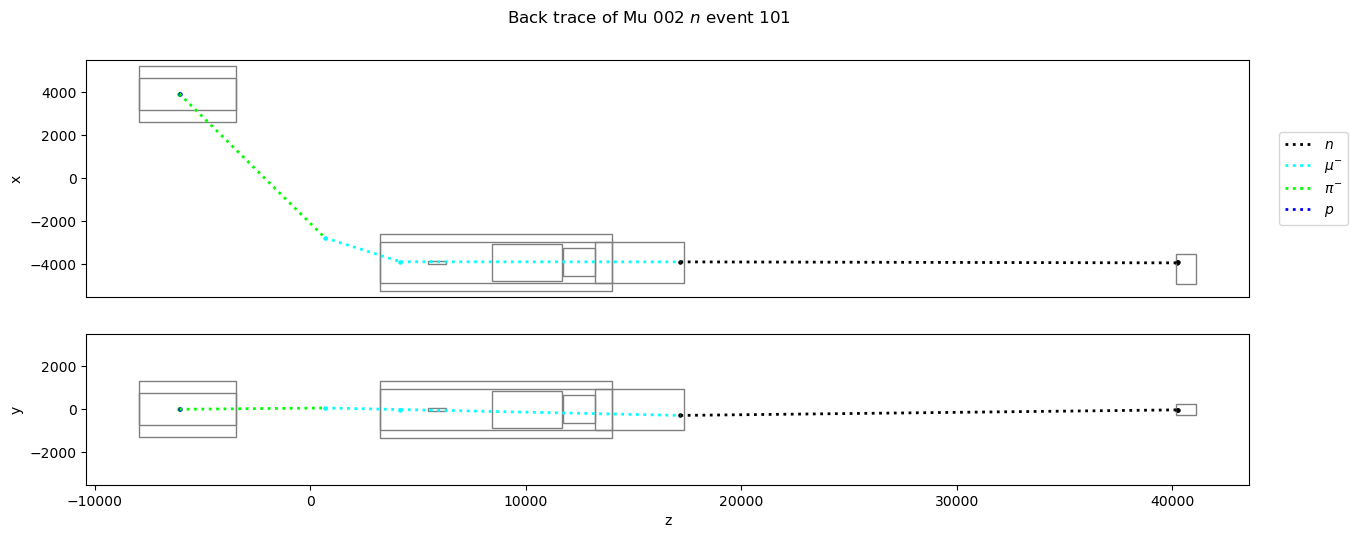

------------------------------------------------------------------------------


level_0                      2601
tag                            Mu
fileno                          2
index                         201
time                  1919.693501
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3836.321206
y                       73.056745
z                        40185.38
startx               -3135.657569
starty                  -852.1418
startz               16616.343334
starttime              488.388641
E                     1424.010505
weight                   1.005488
Name: 2400, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,14191,Mu,2,201,427.291229,488.388641,97,2112,-3712.067213,-401.105758,15571.725111,2.286420e+03
1,14192,Mu,2,201,426.043610,427.291229,97,2112,-3688.359478,-393.785906,15590.825001,3.309802e+03
2,14193,Mu,2,201,420.068573,426.043610,115,2112,-3719.923096,-348.583886,15306.954180,1.475127e+04
3,14194,Mu,2,201,48.222092,125.282204,56,13,-3782.633352,-19.223331,4179.000000,1.763932e+04
4,14195,Mu,2,201,-26.681883,48.351524,14,13,3530.783489,-14.813748,-1367.443261,1.817346e+04
5,14196,Mu,2,201,-55.265560,-26.681883,14,-211,3911.935281,5.494819,-6060.937245,3.818208e+04
6,14197,Mu,2,201,-55.550812,-55.265560,101,3122,3929.439380,1.172390,-6059.914940,2.574088e+04
7,14198,Mu,2,201,-55.558754,-55.550812,56,2212,3930.013172,1.172315,-6057.618313,8.000000e+06


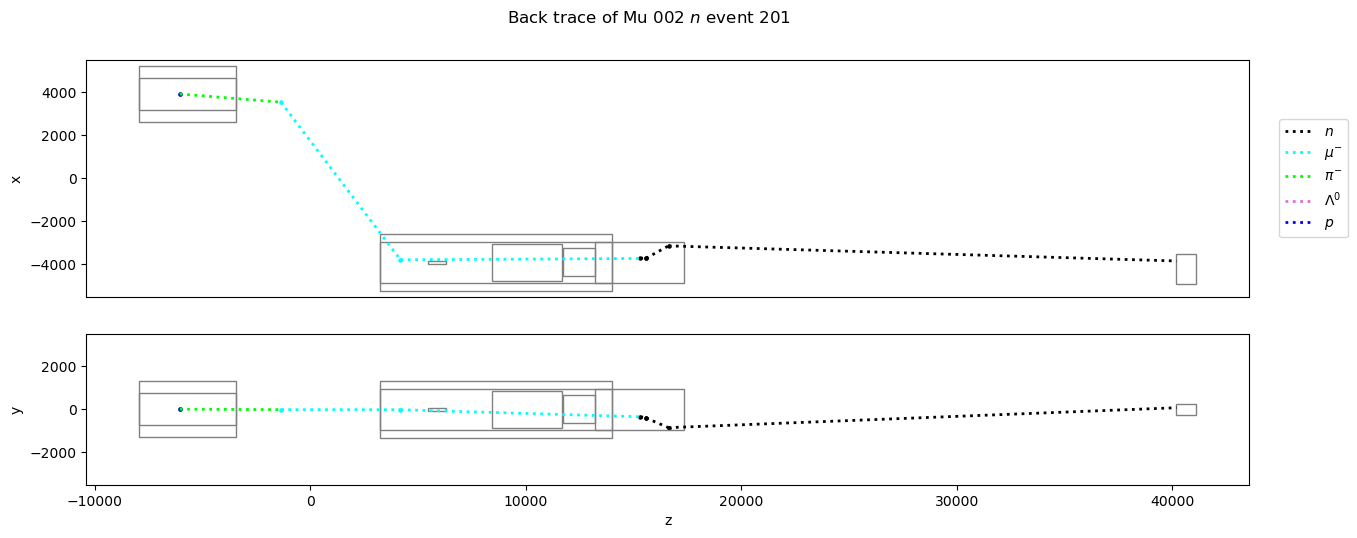

------------------------------------------------------------------------------


level_0                       2701
tag                             Mu
fileno                           2
index                          301
time                 230242.239136
virtualdetectorId              101
creationCode                   115
pdgId                         2112
x                     -3873.409461
y                        -1.772394
z                          40185.4
startx                -3960.856117
starty                  -44.533126
startz                 6271.043971
starttime              2185.300537
E                         0.067168
weight                    1.005488
Name: 2500, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,14756,Mu,2,301,249.829147,279.112305,56,13,-3983.241981,-32.080050,4179.000000,7.883967e+03
1,14757,Mu,2,301,38.539925,250.011353,14,13,3870.648446,-35.998095,-5463.154837,9.669926e+03
2,14758,Mu,2,301,20.696596,38.539925,101,-211,3908.047256,0.288048,-6153.358802,2.850397e+04
3,14759,Mu,2,301,20.367134,20.696596,56,2212,3930.934272,0.329336,-6057.847969,8.000000e+06


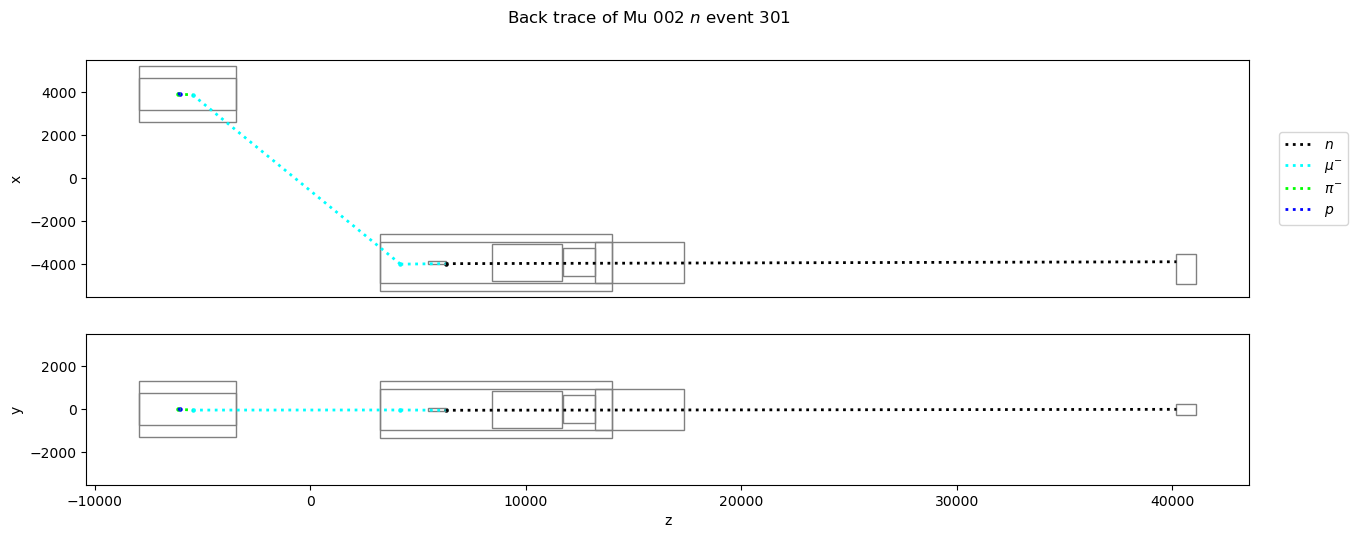

------------------------------------------------------------------------------


level_0                     2801
tag                           Mu
fileno                         2
index                        401
time                 2405.400684
virtualdetectorId            101
creationCode                 115
pdgId                       2112
x                   -3964.833133
y                     -77.646087
z                        40185.4
startx              -3964.655719
starty                  36.15792
startz                6270.99495
starttime            1304.672241
E                    5003.115203
weight                  1.005488
Name: 2600, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,15293,Mu,2,401,200.878418,227.054672,56,13,-3946.671402,-19.779090,4179.000000,7.100794e+03
1,15294,Mu,2,401,-9.274997,201.069443,14,13,3910.530114,13.810775,-5184.218019,9.048573e+03
2,15295,Mu,2,401,-20.133118,-9.274997,101,-211,3905.172243,-0.236418,-6160.591745,3.662117e+04
3,15296,Mu,2,401,-20.488441,-20.133118,56,2212,3931.184380,0.158783,-6057.910328,8.000000e+06


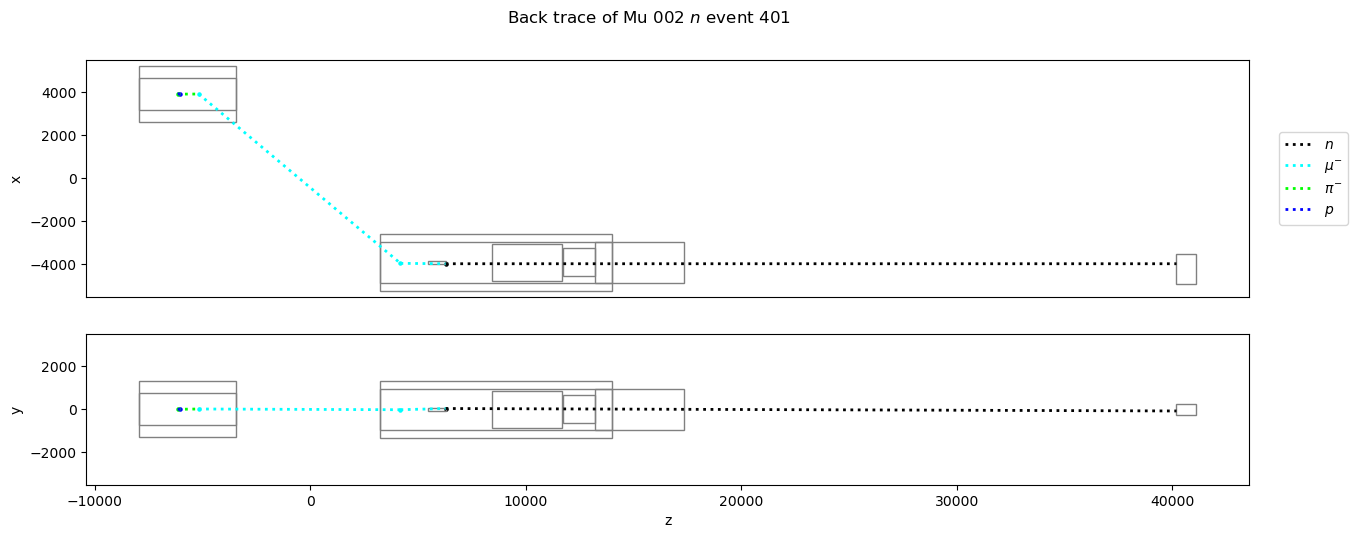

------------------------------------------------------------------------------


level_0                      2901
tag                            Mu
fileno                          2
index                         501
time                  4117.516624
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3899.211786
y                      -10.540318
z                         40185.4
startx               -3908.111874
starty                  62.788798
startz               40221.005947
starttime             4106.686035
E                      586.462488
weight                   1.005488
Name: 2700, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,15851,Mu,2,501,3656.594238,4106.686035,115,2112,-3934.863664,34.723791,5848.825816,3.205231e+04
1,15852,Mu,2,501,208.743591,230.901718,56,13,-3926.258159,50.921982,4179.000000,5.530478e+03
2,15853,Mu,2,501,6.390653,208.957794,14,13,3881.027051,-1.797985,-6168.781317,7.532992e+03
3,15854,Mu,2,501,3.841906,6.390653,101,-211,3885.518266,1.820210,-6244.445020,2.848525e+04
4,15855,Mu,2,501,3.197624,3.841906,56,2212,3930.520189,1.959202,-6057.744727,8.000000e+06


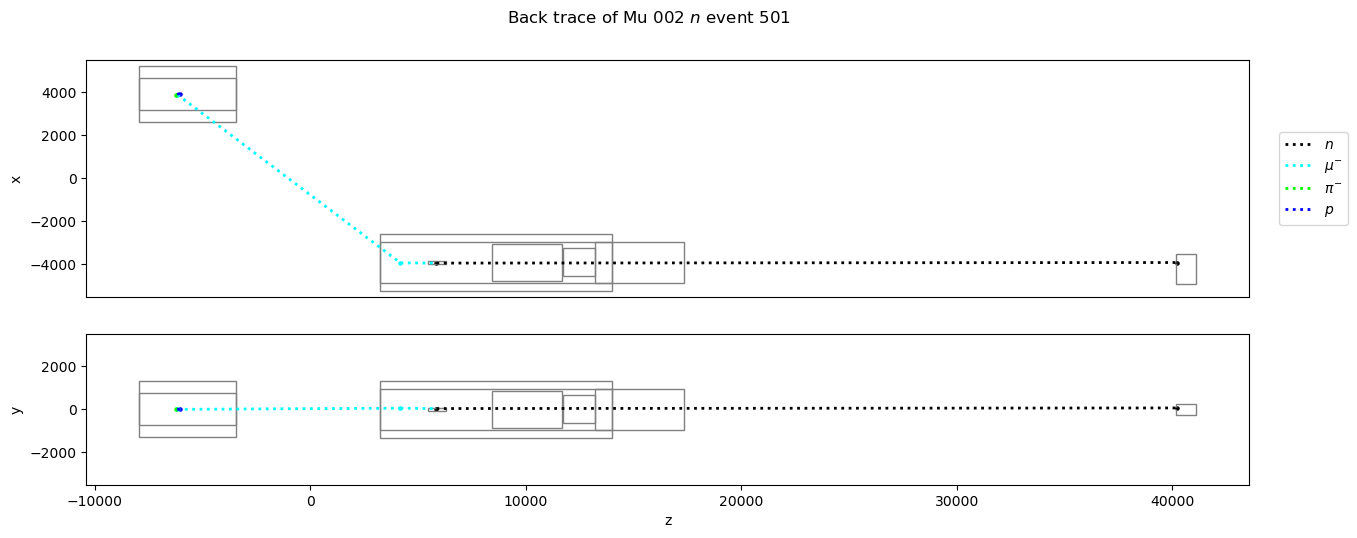

------------------------------------------------------------------------------


level_0                      3001
tag                            Mu
fileno                          2
index                         601
time                 62609.390093
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3982.669306
y                      -32.298663
z                         40185.4
startx               -3820.009179
starty                 168.729139
startz               17376.975015
starttime              718.830505
E                         0.00017
weight                   1.005488
Name: 2800, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,16416,Mu,2,601,714.164124,718.830505,97,2112,-3807.945719,186.497431,17250.708844,1.077457e+04
1,16417,Mu,2,601,689.802856,714.164124,115,2112,-4167.673808,223.653980,15781.226996,2.084443e+04
2,16418,Mu,2,601,134.782303,254.155884,56,13,-4004.850394,54.326374,4179.000000,7.505608e+03
3,16419,Mu,2,601,-6.338945,134.968597,14,13,3797.476976,0.780521,-3809.171728,8.381608e+03
4,16420,Mu,2,601,-22.729980,-6.338945,101,-211,3888.875538,0.014794,-6221.959235,7.516570e+04
5,16421,Mu,2,601,-23.298317,-22.729980,56,2212,3929.879527,-0.404283,-6057.584992,8.000000e+06


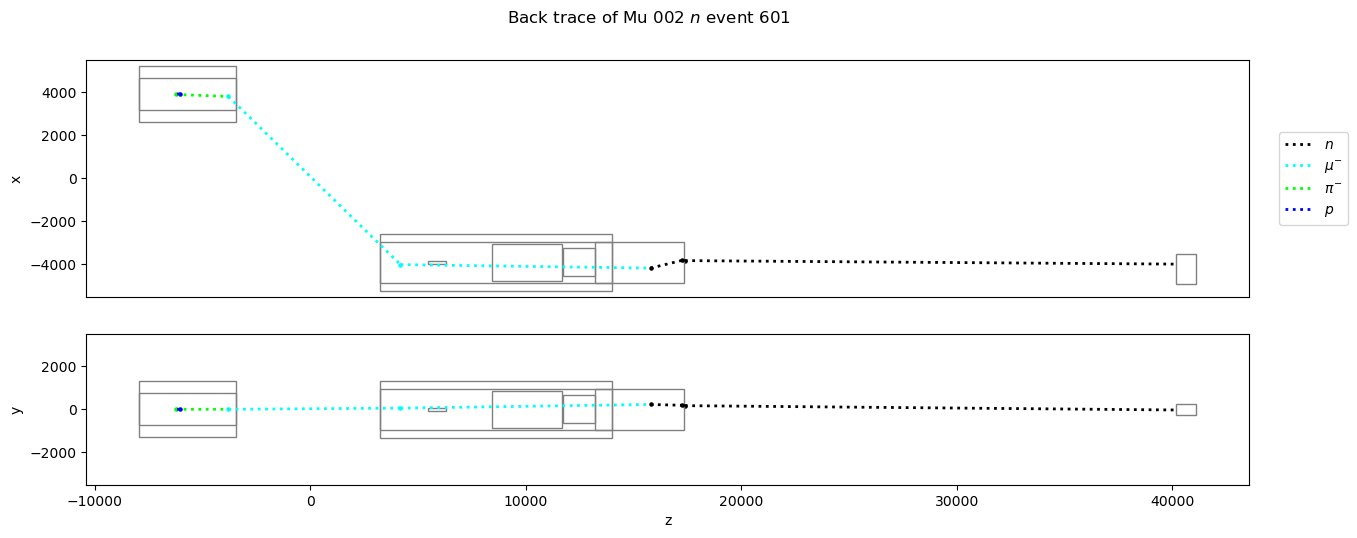

------------------------------------------------------------------------------


level_0                      3101
tag                            Mu
fileno                          2
index                         701
time                   550.790948
virtualdetectorId             101
creationCode                  109
pdgId                        2112
x                    -3927.241065
y                      -16.800464
z                         40185.4
startx               -3875.463159
starty                  -5.494406
startz               40214.196936
starttime              514.035156
E                      249.379212
weight                   1.005488
Name: 2900, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,16935,Mu,2,701,513.010193,513.035156,16,22,-3873.938329,-4.287206,40206.973079,1.477730e+04
1,16936,Mu,2,701,386.848602,513.010803,114,11,-3867.225543,-43.080045,5693.230277,3.629701e+04
2,16937,Mu,2,701,207.815262,228.984848,56,13,-3906.850735,-30.347147,4179.000000,4.743566e+03
3,16938,Mu,2,701,2.567065,208.045334,14,13,3916.021626,-51.566499,-6088.408409,6.299753e+03
4,16939,Mu,2,701,-2.825805,2.567065,101,-211,3889.189465,-0.494160,-6219.948509,2.680684e+04
5,16940,Mu,2,701,-3.387357,-2.825805,56,2212,3930.518173,-0.003167,-6057.744224,8.000000e+06


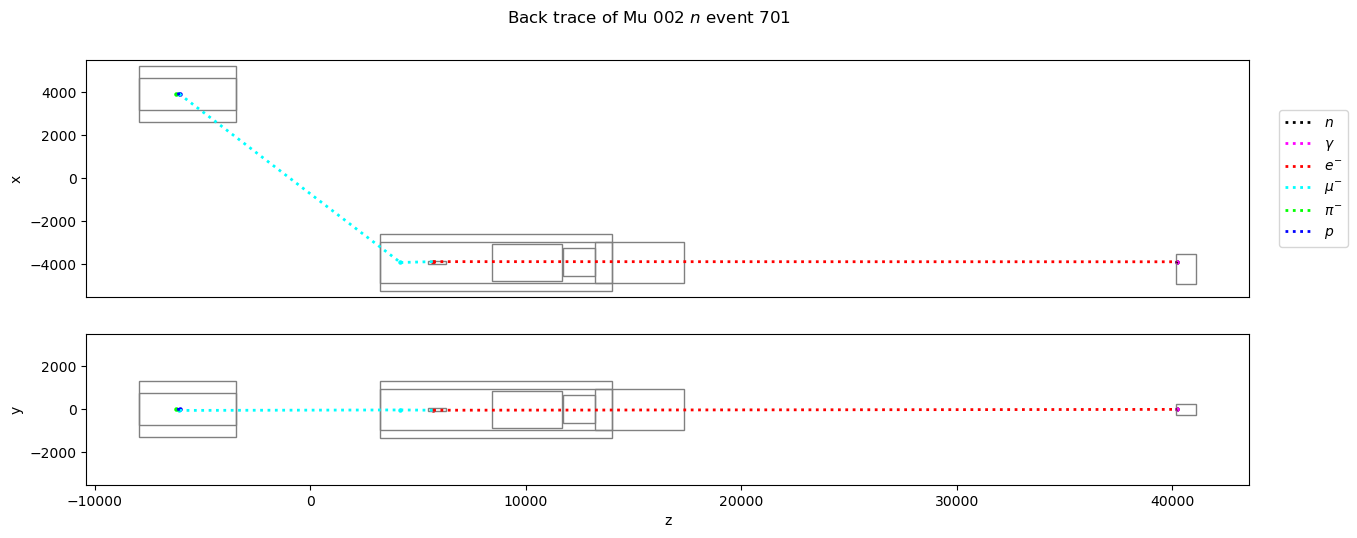

------------------------------------------------------------------------------


level_0                      3201
tag                            Mu
fileno                          2
index                         801
time                  2002.942538
virtualdetectorId             101
creationCode                  115
pdgId                        2112
x                    -3876.372242
y                       50.394661
z                         40185.4
startx               -4248.317783
starty                 -21.247272
startz               16393.835944
starttime             1059.254761
E                     3351.529665
weight                   1.005488
Name: 3000, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,17481,Mu,2,801,221.799103,444.973663,56,13,-3902.202220,-38.215002,4179.000000,7.673122e+03
1,17482,Mu,2,801,36.154835,221.983551,14,13,3879.791822,6.432760,-4564.408125,9.314877e+03
2,17483,Mu,2,801,21.858038,36.154835,101,-211,3887.941555,1.697901,-6236.540290,4.730497e+04
3,17484,Mu,2,801,21.241392,21.858038,56,2212,3931.895480,-1.082840,-6058.087625,8.000000e+06


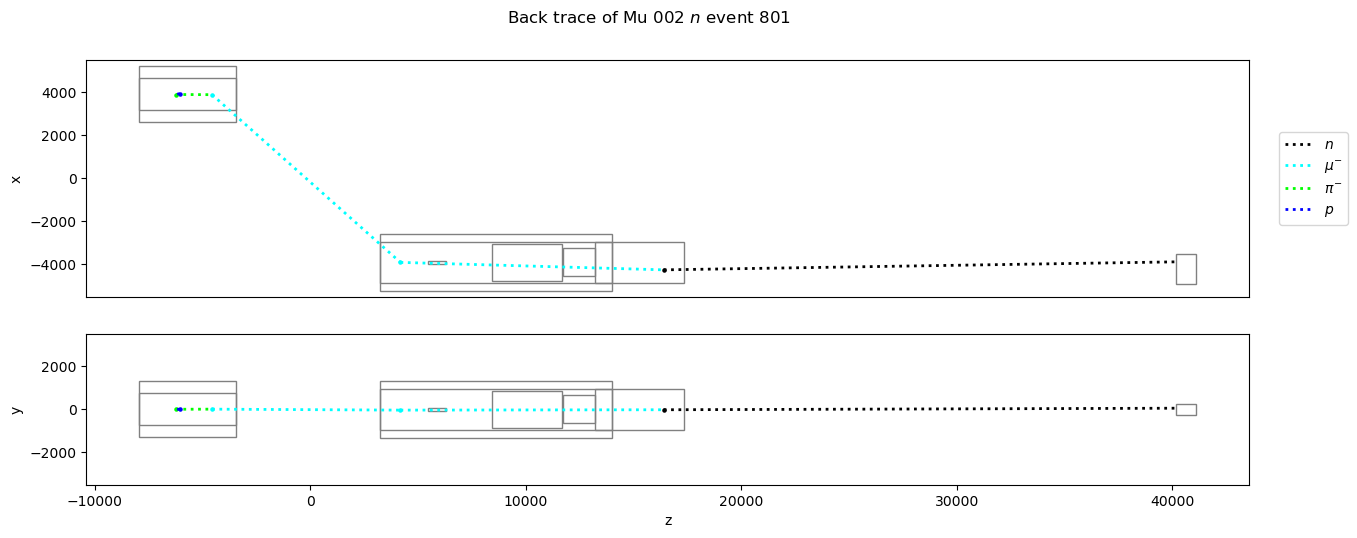

------------------------------------------------------------------------------


level_0                        3301
tag                              Mu
fileno                            2
index                           901
time                 7714574.490963
virtualdetectorId               101
creationCode                    115
pdgId                          2112
x                      -3974.495717
y                        -59.494453
z                          40185.38
startx                 -3883.259299
starty                    -8.022764
startz                  5648.801329
starttime                 625.59137
E                          0.000055
weight                     1.005488
Name: 3100, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,18024,Mu,2,901,292.113800,315.078766,56,13,-3875.870328,25.649286,4179.000000,5.278599e+03
1,18025,Mu,2,901,28.501842,292.332672,14,13,3927.113099,7.923021,-5425.625312,8.074247e+03
2,18026,Mu,2,901,13.321326,28.501842,101,-211,3927.873688,-0.567259,-6074.187722,2.749065e+04
3,18027,Mu,2,901,13.265662,13.321326,56,2212,3931.993929,-0.508764,-6058.112171,8.000000e+06


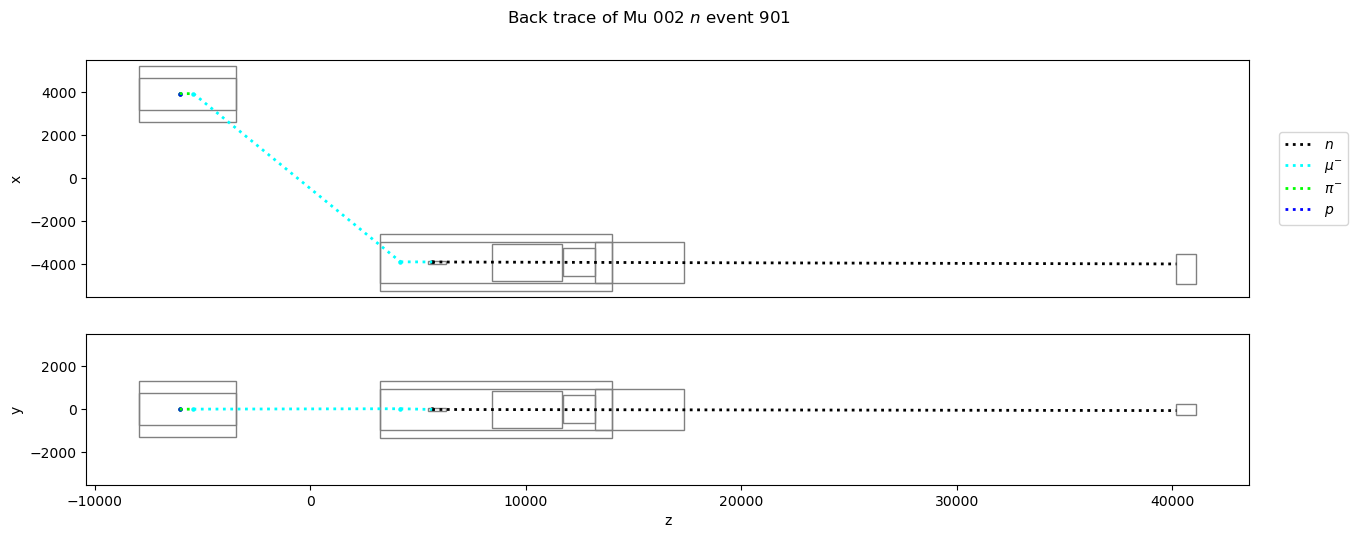

------------------------------------------------------------------------------


level_0                      3401
tag                            Mu
fileno                          2
index                        1001
time                 48821.412994
virtualdetectorId             101
creationCode                  115
pdgId                        2112
x                    -3892.315993
y                      -31.973376
z                         40185.4
startx                -3919.01975
starty                  31.122745
startz                6271.007758
starttime             1099.879272
E                        3.146891
weight                   1.005488
Name: 3200, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,18535,Mu,2,1001,89.498024,110.561745,56,13,-3892.698606,20.718274,4179.000000,7.957056e+03
1,18536,Mu,2,1001,-44.229816,89.679482,14,13,3906.078663,6.345211,-5729.303897,9.420254e+03
2,18537,Mu,2,1001,-47.080036,-44.229816,101,-211,3914.859606,0.788226,-6124.501717,3.575634e+04
3,18538,Mu,2,1001,-47.310024,-47.080036,56,2212,3931.324005,0.593052,-6057.945140,8.000000e+06


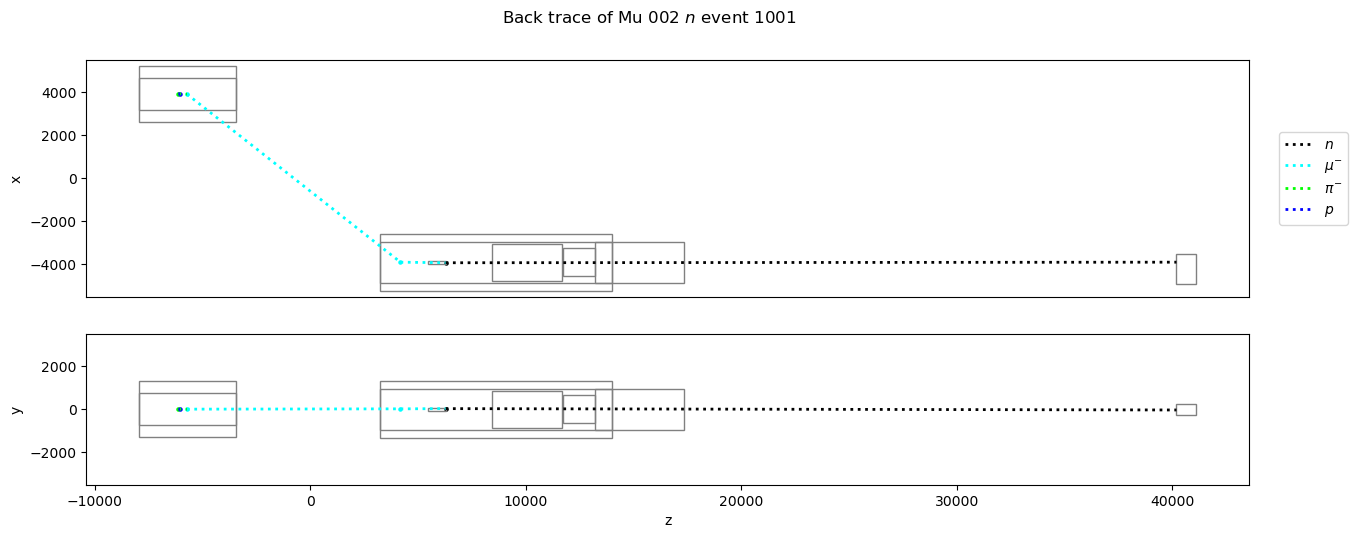

------------------------------------------------------------------------------


level_0                      3501
tag                            Mu
fileno                          3
index                           3
time                  1286.047611
virtualdetectorId             101
creationCode                  115
pdgId                        2112
x                    -3834.938758
y                      -21.819826
z                        40185.38
startx               -3685.275161
starty                 177.905476
startz               17156.223777
starttime              807.322754
E                    12429.347241
weight                   1.005488
Name: 3300, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,19044,Mu,3,3,188.789368,436.609070,56,13,-3908.923736,0.094774,4179.000000,9.939866e+03
1,19045,Mu,3,3,65.611061,188.953827,14,13,3910.892901,-9.328549,-3855.545749,1.074689e+04
2,19046,Mu,3,3,35.621704,65.611061,101,-211,3908.471591,-0.528003,-6144.294427,1.406530e+04
3,19047,Mu,3,3,35.322105,35.621704,56,2212,3930.255033,-0.879144,-6057.678616,8.000000e+06


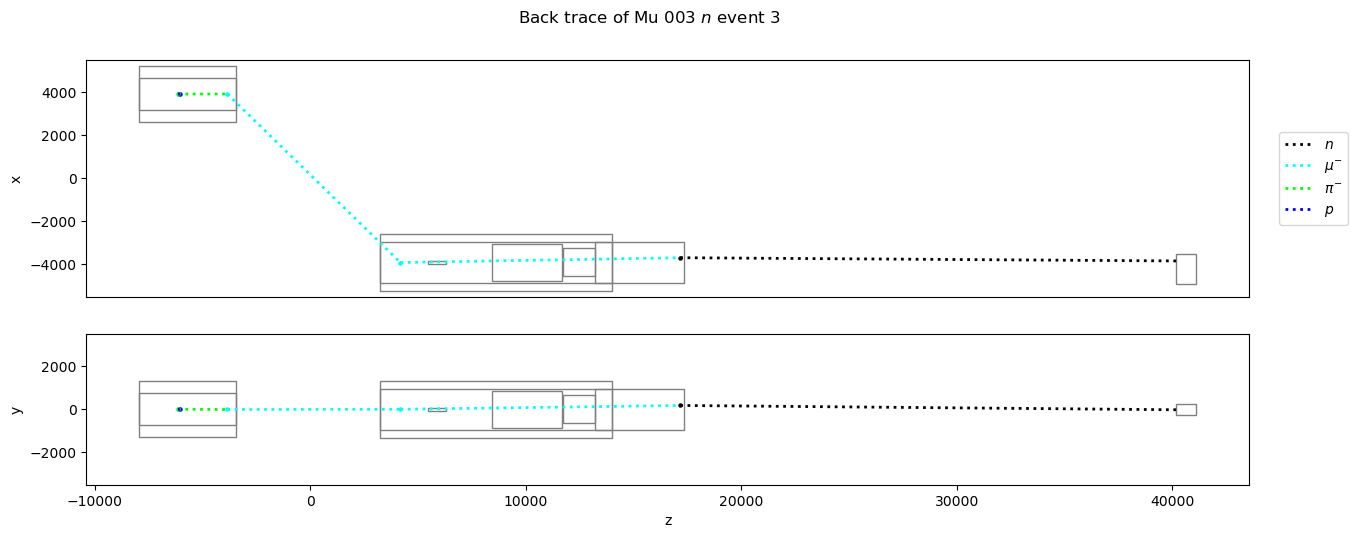

------------------------------------------------------------------------------


level_0                      3601
tag                            Mu
fileno                          3
index                         103
time                 13157.921204
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3932.482143
y                      -58.236632
z                        40185.38
startx               -3745.692398
starty                 789.673007
startz                8563.526774
starttime             1656.792847
E                        6.214715
weight                   1.005488
Name: 3400, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,19548,Mu,3,103,1598.638794,1656.792847,115,2112,-3843.220420,-24.024011,5982.146555,1.154656e+04
1,19549,Mu,3,103,176.157532,196.247589,56,13,-3859.264091,0.387238,4179.000000,6.512401e+03
2,19550,Mu,3,103,28.884409,176.356216,14,13,3971.309937,-0.715019,-4685.128518,8.096270e+03
3,19551,Mu,3,103,2.041147,28.884409,101,-211,3915.554849,1.342222,-6118.241918,3.192760e+04
4,19552,Mu,3,103,1.832099,2.041147,56,2212,3930.445550,1.149300,-6057.726117,8.000000e+06


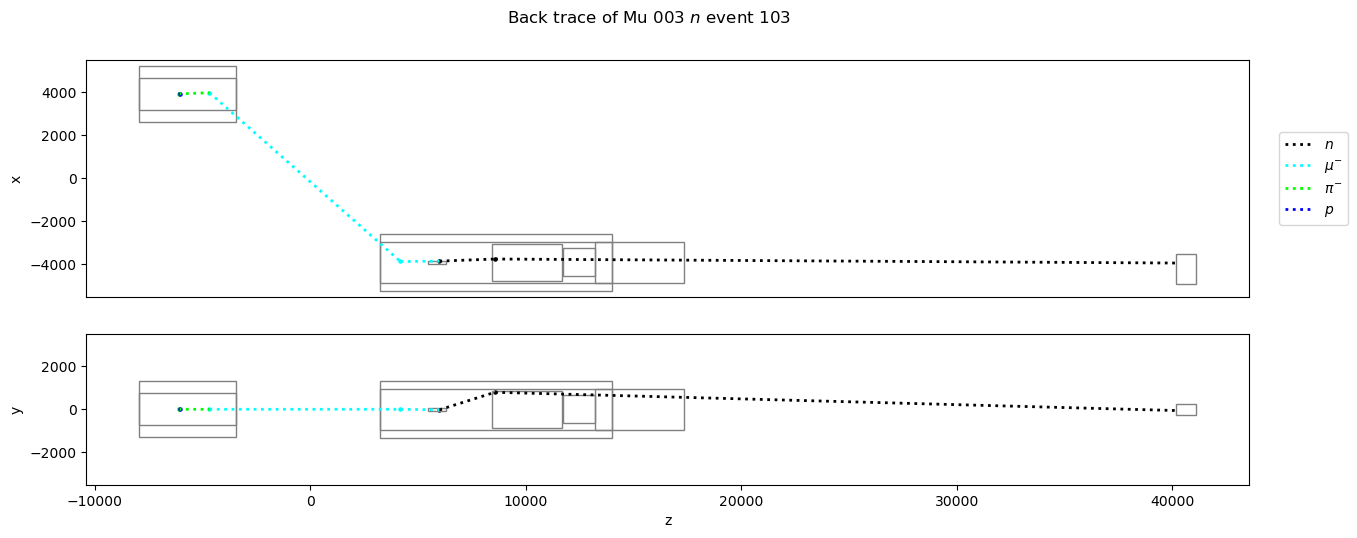

------------------------------------------------------------------------------


level_0                         3701
tag                               Mu
fileno                             3
index                            203
time                 23756480.539474
virtualdetectorId                101
creationCode                     115
pdgId                           2112
x                       -3856.056567
y                         -77.644713
z                           40185.38
startx                  -4223.656948
starty                     -9.558787
startz                  17151.596038
starttime                 542.649292
E                           0.000026
weight                      1.005488
Name: 3500, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,20074,Mu,3,203,72.934959,198.101364,56,13,-3872.510540,5.079012,4179.000000,1.299570e+04
1,20075,Mu,3,203,-37.749352,73.081573,14,13,3871.366518,43.493457,-3470.719749,1.374595e+04
2,20076,Mu,3,203,-56.145313,-37.749352,97,-211,3913.963824,-2.478516,-6120.377932,5.027858e+04
3,20077,Mu,3,203,-56.172810,-56.145313,101,2112,3916.624193,-1.161084,-6112.804391,4.853038e+06
4,20078,Mu,3,203,-56.363293,-56.172810,56,2212,3930.638002,-1.209650,-6057.774101,8.000000e+06


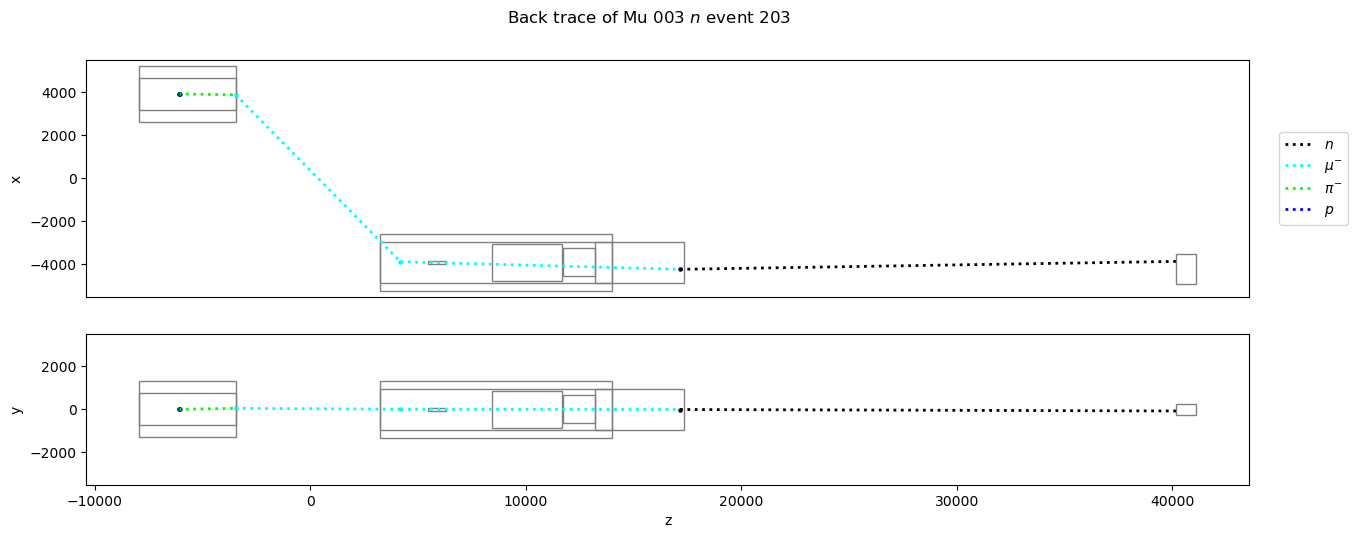

------------------------------------------------------------------------------


level_0                      3801
tag                            Mu
fileno                          3
index                         303
time                 31194.055564
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3911.729052
y                      -90.656686
z                         40185.4
startx               -3704.261922
starty                1083.883225
startz                8521.211913
starttime              785.271057
E                        4.591848
weight                   1.005488
Name: 3600, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,20599,Mu,3,303,686.676147,785.271057,115,2112,-3883.409461,-13.325452,6204.345502,5.857822e+03
1,20600,Mu,3,303,150.712875,172.601395,56,13,-3931.750208,2.242029,4179.000000,8.750280e+03
2,20601,Mu,3,303,-2.115598,150.886810,14,13,3881.689946,-4.394723,-6120.259520,1.022905e+04
3,20602,Mu,3,303,-2.405370,-2.115598,101,-211,3911.962170,-0.938971,-6132.011873,3.058091e+04
4,20603,Mu,3,303,-2.662155,-2.405370,56,2212,3930.366156,-1.100748,-6057.706322,8.000000e+06


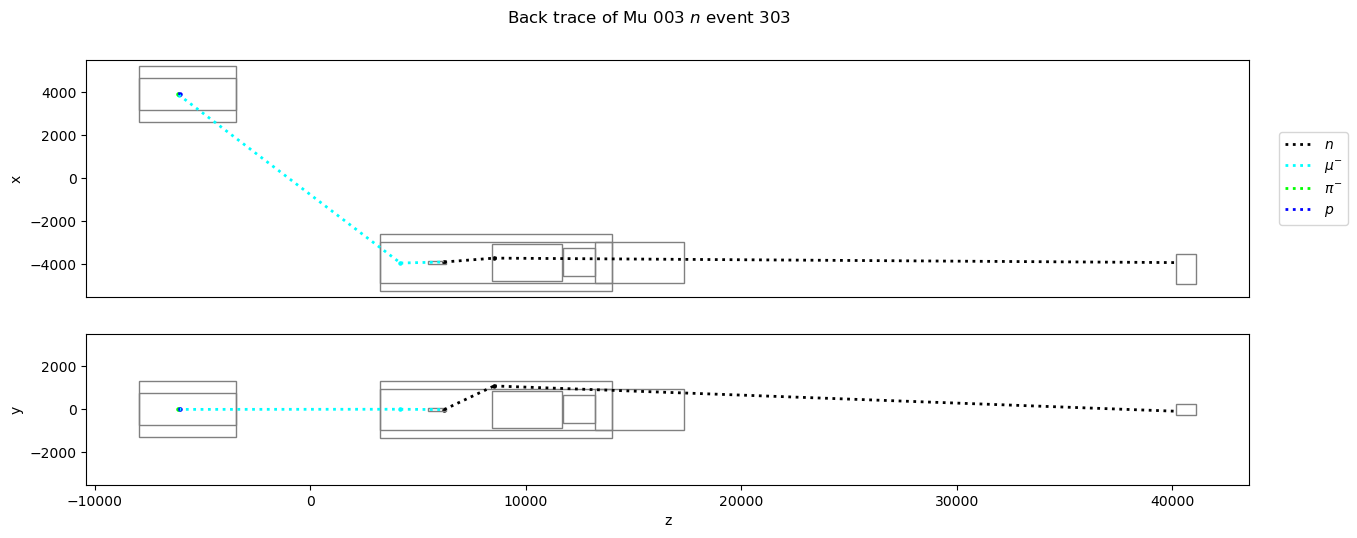

------------------------------------------------------------------------------


level_0                      3901
tag                            Mu
fileno                          3
index                         403
time                  7124.353972
virtualdetectorId             101
creationCode                  109
pdgId                        2112
x                    -3812.985306
y                        0.313557
z                        40185.38
startx               -3500.437986
starty                1018.371154
startz               16808.892934
starttime             5080.725586
E                       53.683947
weight                   1.005488
Name: 3700, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,21130,Mu,3,403,5076.910645,5079.725586,16,22,-3696.151200,266.019900,17137.370826,1.891197e+04
1,21131,Mu,3,403,5076.715332,5076.934082,114,11,-3705.233110,214.033230,17162.108294,3.957751e+04
2,21132,Mu,3,403,101.762604,216.721939,56,13,-3877.702945,5.459753,4179.000000,1.579289e+04
3,21133,Mu,3,403,39.450859,101.897888,14,13,1431.436480,145.911222,-44.922132,1.638211e+04
4,21134,Mu,3,403,-24.359543,39.450859,97,-211,3903.332416,0.614671,-6169.050489,3.923963e+04
5,21135,Mu,3,403,-24.397526,-24.359543,101,2112,3905.805331,1.423680,-6158.154988,4.293574e+06
6,21136,Mu,3,403,-24.744410,-24.397526,56,2212,3930.980033,1.363415,-6057.859379,8.000000e+06


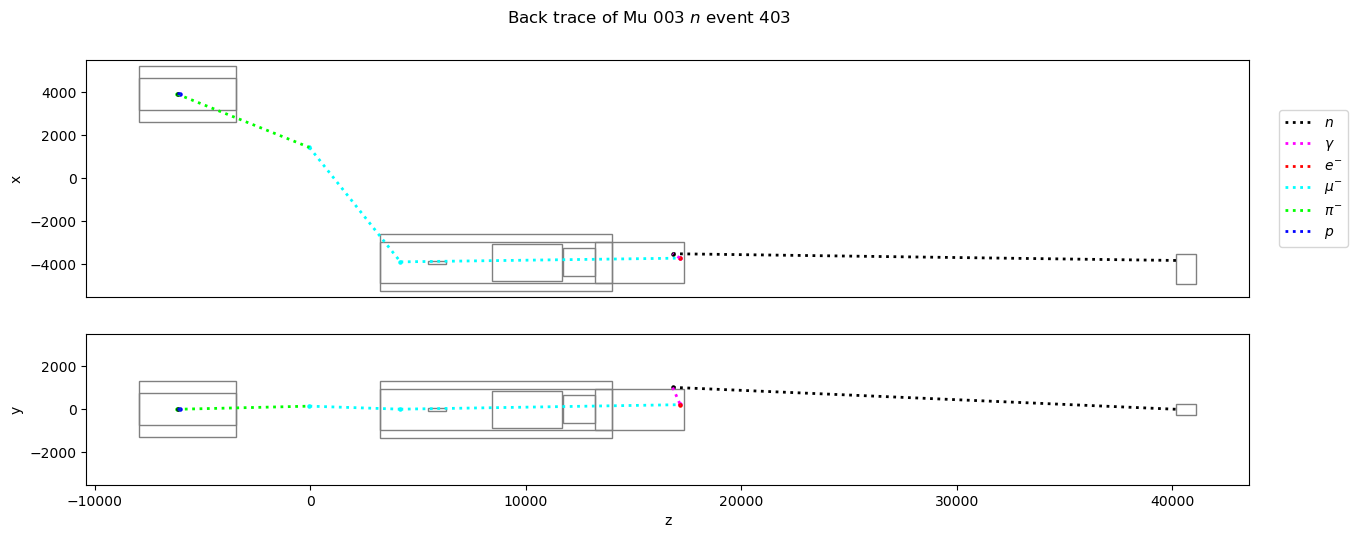

------------------------------------------------------------------------------


level_0                     4001
tag                           Mu
fileno                         3
index                        503
time                  5449.67371
virtualdetectorId            101
creationCode                  97
pdgId                       2112
x                   -3914.990719
y                       46.52951
z                        40185.4
startx              -3900.557374
starty                  8.021963
startz               40255.78181
starttime            5394.595703
E                      66.345942
weight                  1.005488
Name: 3800, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,21683,Mu,3,503,509.457581,5394.595703,97,2112,-4592.119542,-681.400370,5434.907733,1.072974e+03
1,21684,Mu,3,503,503.220276,509.457581,97,2112,-4711.455085,-685.616350,5564.169978,4.188571e+03
2,21685,Mu,3,503,501.552216,503.220276,97,2112,-4679.534387,-647.126733,5508.941482,1.060413e+04
3,21686,Mu,3,503,481.698303,501.552216,115,2112,-3913.587829,43.734841,5648.726543,1.470610e+04
4,21687,Mu,3,503,191.759903,211.595367,56,13,-3891.269483,58.181261,4179.000000,4.802944e+03
5,21688,Mu,3,503,21.812292,191.988632,14,13,3915.745782,21.861272,-5614.577015,6.783400e+03
6,21689,Mu,3,503,6.714547,21.812292,101,-211,3912.135600,-0.199065,-6131.393573,2.020217e+04
7,21690,Mu,3,503,6.459919,6.714547,56,2212,3930.700760,-0.171462,-6057.789748,8.000000e+06


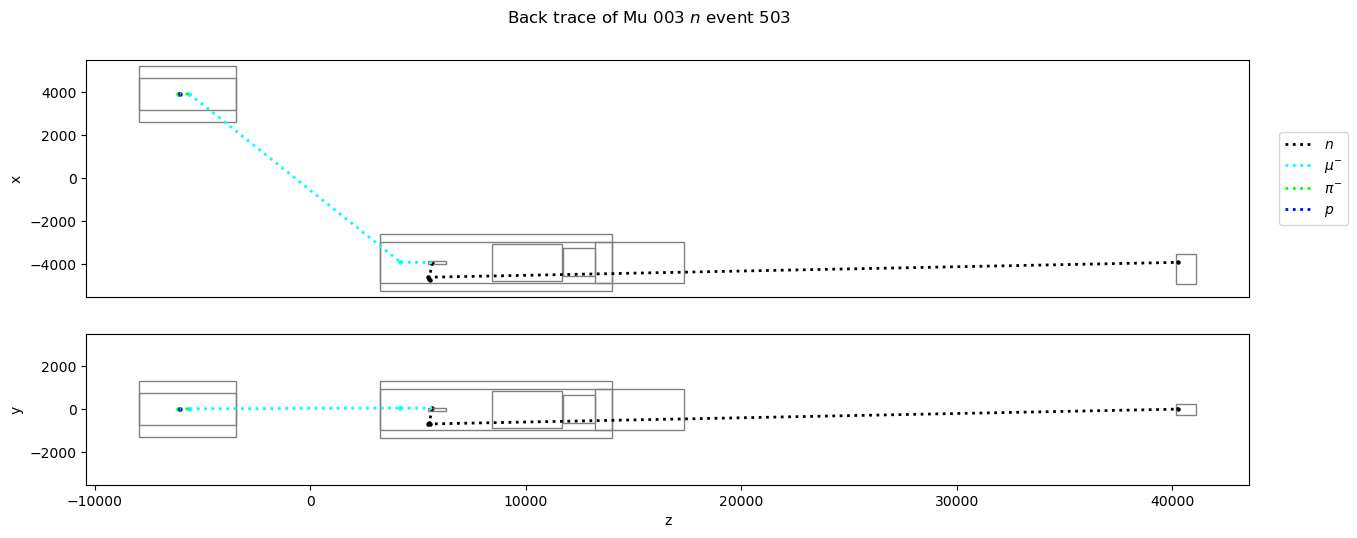

------------------------------------------------------------------------------


level_0                      4101
tag                            Mu
fileno                          3
index                         603
time                 11446.837956
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3982.445652
y                      -55.240649
z                         40185.4
startx                -5153.79757
starty               -1201.646579
startz               15075.401066
starttime              528.816162
E                       45.189182
weight                   1.005488
Name: 3900, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,22196,Mu,3,603,455.232666,528.816162,97,2112,-4099.617739,-421.179070,16057.256320,3.056542e+03
1,22197,Mu,3,603,450.656372,455.232666,115,2112,-4037.939925,-323.021887,15956.282372,7.389797e+03
2,22198,Mu,3,603,89.879807,162.495026,56,13,-3873.150189,-8.537375,4179.000000,2.328471e+04
3,22199,Mu,3,603,-1.700953,89.996201,14,13,3908.368197,-12.799338,-5662.151071,2.404434e+04
4,22200,Mu,3,603,-4.770771,-1.700953,97,-211,3904.403468,2.719956,-6162.199324,6.736844e+04
5,22201,Mu,3,603,-4.808104,-4.770771,101,2112,3906.807720,1.966147,-6152.028239,1.734490e+06
6,22202,Mu,3,603,-5.134240,-4.808104,56,2212,3930.603880,1.282300,-6057.765593,8.000000e+06


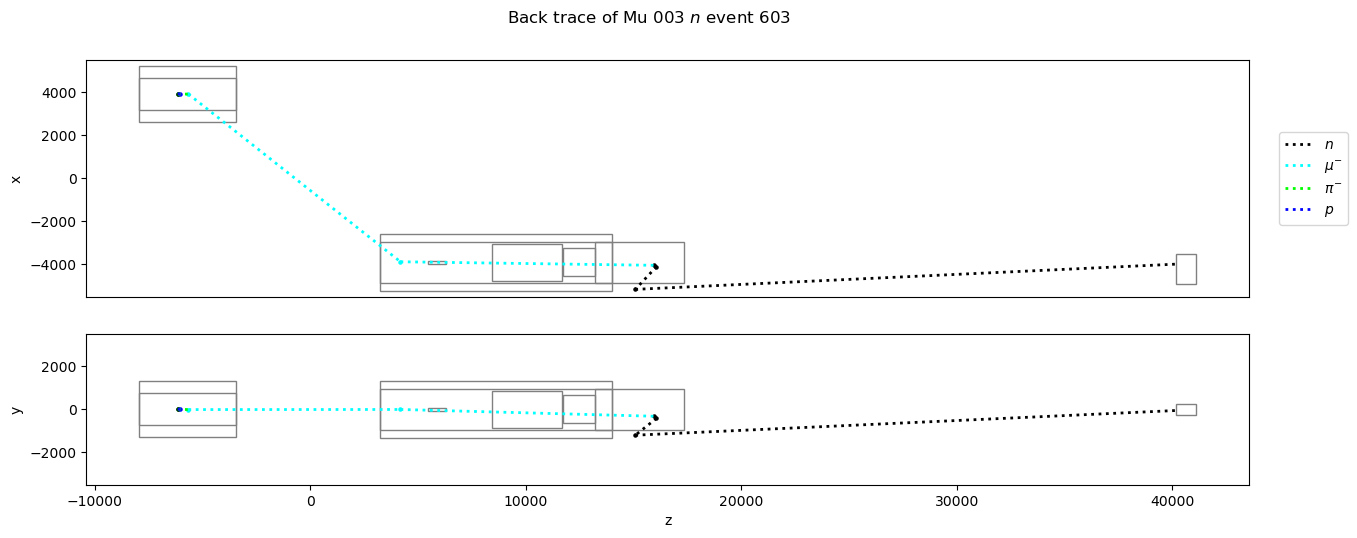

------------------------------------------------------------------------------


level_0                      4201
tag                            Mu
fileno                          3
index                         703
time                  8647.693545
virtualdetectorId             101
creationCode                  115
pdgId                        2112
x                    -3822.686386
y                      -42.158974
z                         40185.4
startx               -3930.313428
starty                   9.400589
startz               17415.614011
starttime              307.693665
E                       41.944969
weight                   1.005488
Name: 4000, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,22733,Mu,3,703,179.836777,268.273987,56,13,-3920.120356,-120.354694,4179.000000,2.049666e+04
1,22734,Mu,3,703,71.795677,179.958878,14,13,3864.294189,-2.380167,-5198.807919,2.110976e+04
2,22735,Mu,3,703,52.545086,71.795677,101,-211,3921.283657,0.100246,-6096.443174,5.255909e+04
3,22736,Mu,3,703,52.411640,52.545086,56,2212,3930.881110,0.061358,-6057.834714,8.000000e+06


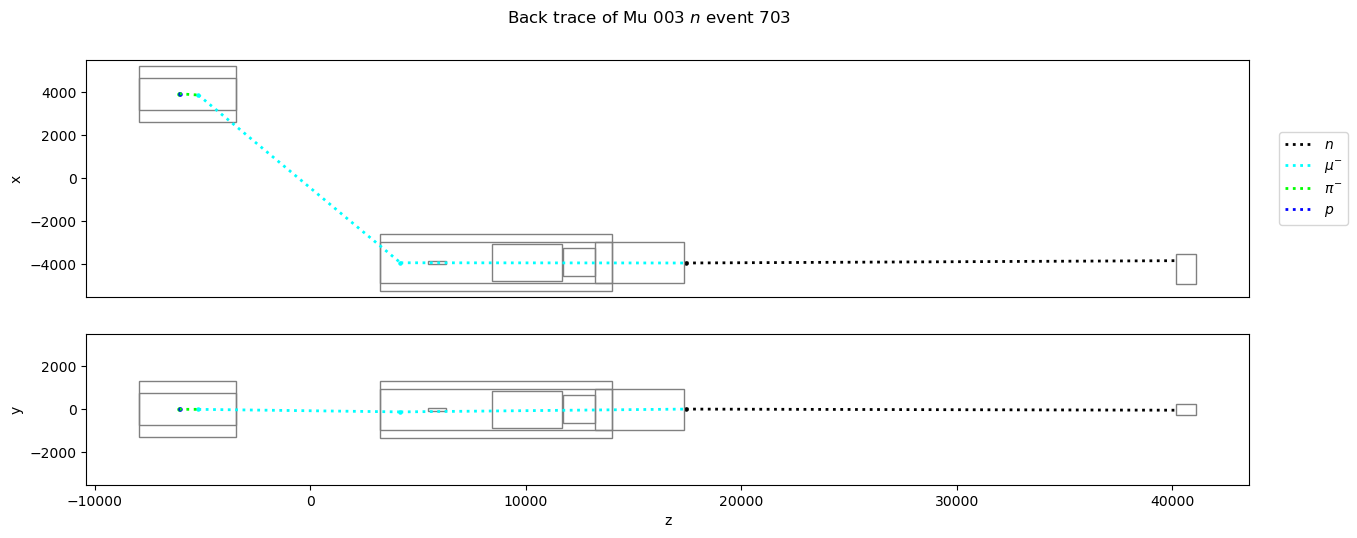

------------------------------------------------------------------------------


level_0                      4301
tag                            Mu
fileno                          3
index                         803
time                 23112.821652
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3900.350519
y                      -42.976958
z                        40185.38
startx               -3111.661977
starty                1039.340127
startz                5468.708153
starttime              367.225708
E                       13.482722
weight                   1.005488
Name: 4100, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,23256,Mu,3,803,328.358948,367.225708,97,2112,-3497.449350,1027.550558,5190.207331,1.045867e+03
1,23257,Mu,3,803,324.515869,328.358948,97,2112,-3523.071828,987.857307,5244.294540,2.187438e+03
2,23258,Mu,3,803,308.748077,324.515869,115,2112,-3908.987234,-36.466561,6048.815860,4.362442e+04
3,23259,Mu,3,803,132.888733,153.933502,56,13,-3930.930274,-60.411967,4179.000000,7.964934e+03
4,23260,Mu,3,803,-35.516548,133.070114,14,13,3901.566654,5.947937,-5628.886774,9.295187e+03
5,23261,Mu,3,803,-40.965130,-35.516548,101,-211,3920.467775,0.290281,-6100.837976,2.810405e+04
6,23262,Mu,3,803,-41.113541,-40.965130,56,2212,3931.224006,0.320743,-6057.920208,8.000000e+06


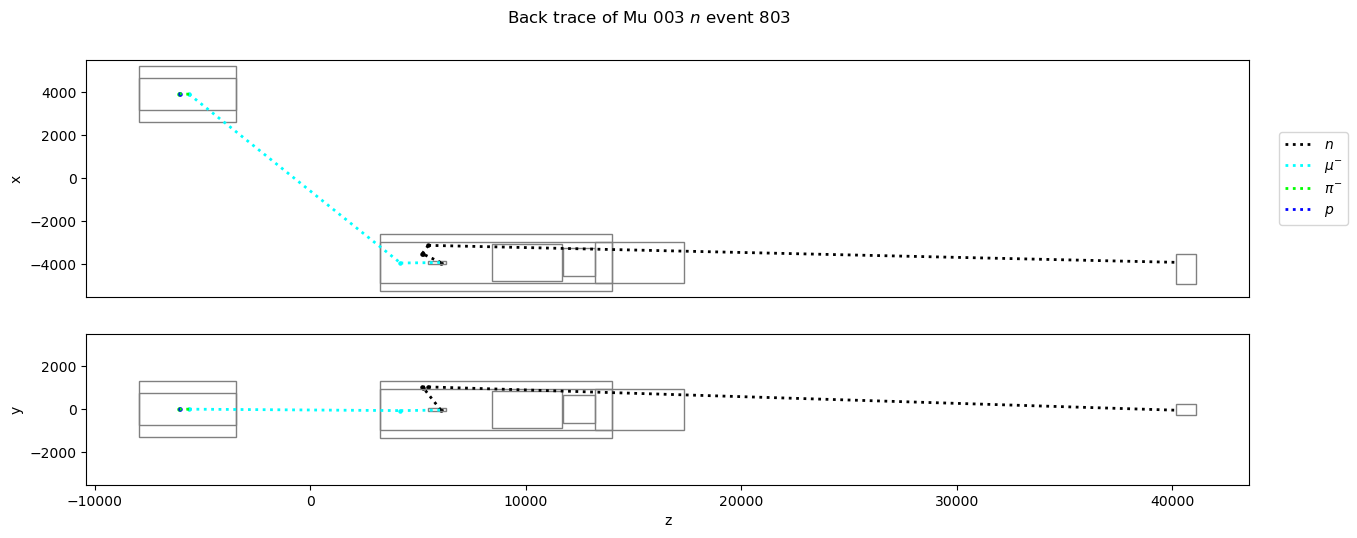

------------------------------------------------------------------------------


level_0                        4401
tag                              Mu
fileno                            3
index                           903
time                 1077822.622588
virtualdetectorId               101
creationCode                     97
pdgId                          2112
x                       -3999.80438
y                         20.015281
z                           40185.4
startx                 -7761.706284
starty                  -795.460855
startz                  2459.076557
starttime               1202.070312
E                          0.002456
weight                     1.005488
Name: 4200, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,23801,Mu,3,903,1199.798340,1202.070312,97,2112,-7727.597061,-815.132310,2431.662515,5.070842e+03
1,23802,Mu,3,903,1066.384521,1199.798340,115,2112,-3860.150646,7.821663,5471.024669,7.390378e+03
2,23803,Mu,3,903,268.276550,299.518433,56,13,-3883.977607,18.162309,4179.000000,1.277185e+03
3,23804,Mu,3,903,-14.881743,268.709503,14,13,3930.769923,6.985114,-5348.886590,4.266981e+03
4,23805,Mu,3,903,-29.783804,-14.881743,101,-211,3930.789556,1.301091,-6059.181884,1.777486e+04
5,23806,Mu,3,903,-29.788263,-29.783804,56,2212,3931.111266,1.301434,-6057.892099,8.000000e+06


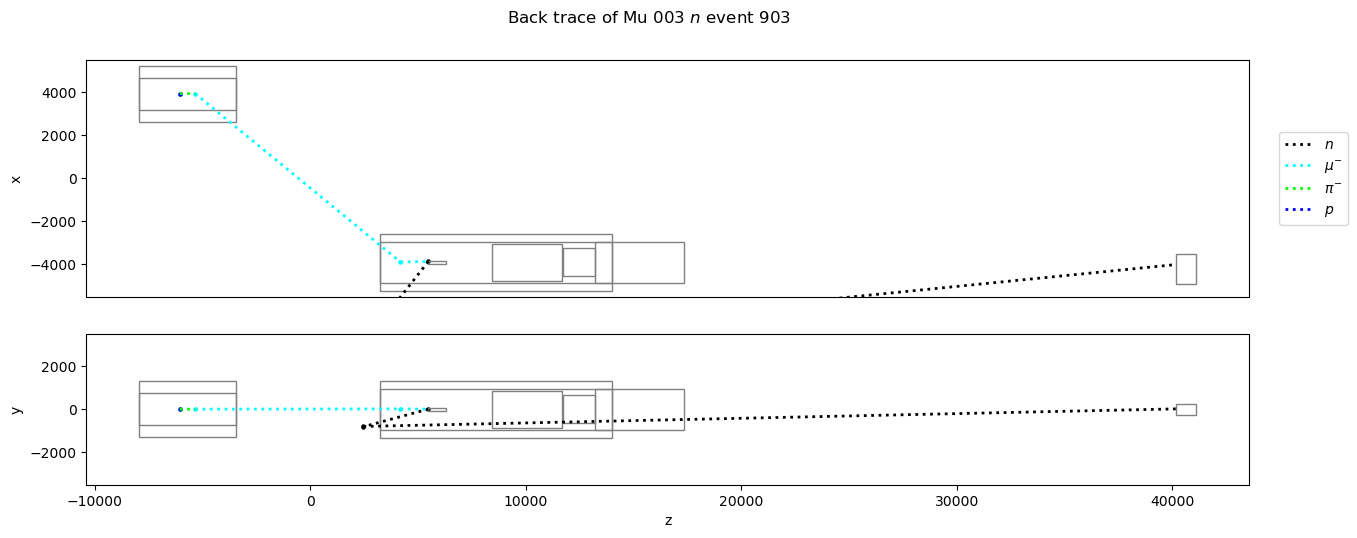

------------------------------------------------------------------------------


level_0                      4501
tag                            Mu
fileno                          3
index                        1003
time                  5610.707839
virtualdetectorId             101
creationCode                  115
pdgId                        2112
x                    -3897.236985
y                      -83.776351
z                         40185.4
startx               -3899.569463
starty                  26.818962
startz               17416.327712
starttime              695.029297
E                        79.09096
weight                   1.005488
Name: 4300, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,E
0,24347,Mu,3,1003,106.601608,193.367538,56,13,-3854.329894,-50.470848,4179.000000,2.122050e+04
1,24348,Mu,3,1003,-0.218011,106.722099,14,13,3854.532053,-27.330440,-5640.155369,2.183337e+04
2,24349,Mu,3,1003,-8.292280,-0.218011,14,-211,3883.690138,9.904226,-6116.190432,1.014735e+04
3,24350,Mu,3,1003,-8.755214,-8.292280,14,3122,3930.002705,-0.420581,-6061.051423,1.943859e+05
4,24351,Mu,3,1003,-8.755214,-8.755214,101,3212,3930.002705,-0.420581,-6061.051423,2.565973e+05
5,24352,Mu,3,1003,-8.766396,-8.755214,56,2212,3930.809979,-0.420792,-6057.816979,8.000000e+06


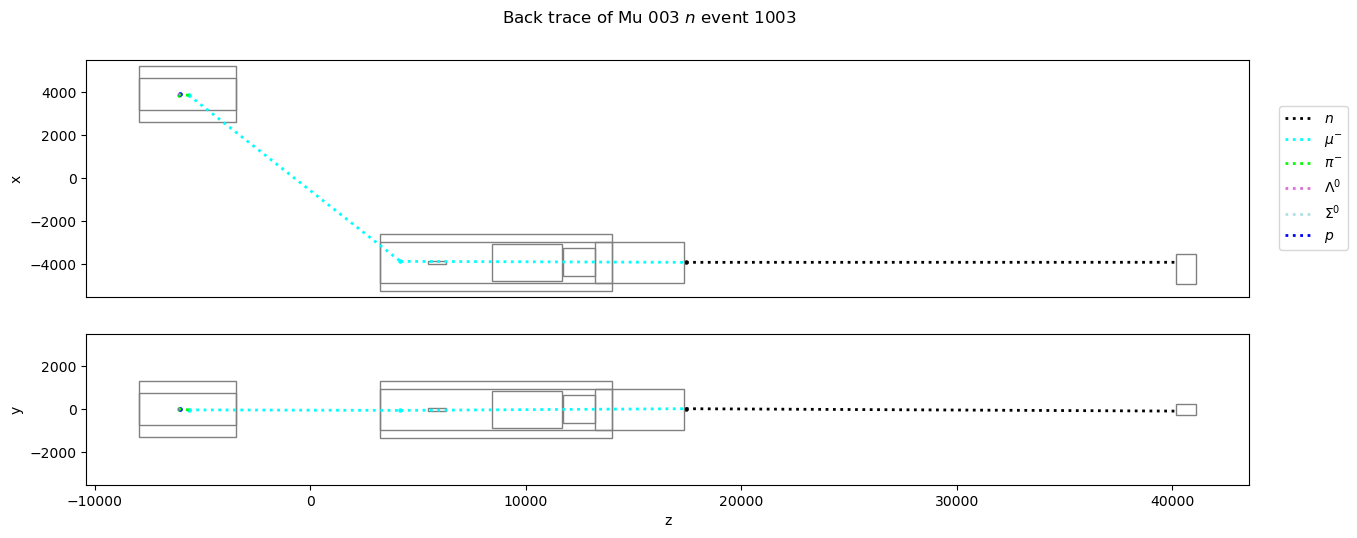

In [6]:
for ii in range(0, len(dfn_Mu), 100):
    print('------------------------------------------------------------------------------')
    dfn_ = dfn_Mu.iloc[ii]
    tag, fileno, index = dfn_['tag'], dfn_['fileno'], dfn_['index']
    dfg_ = df_genealogy.query("tag==@tag and fileno==@fileno and index==@index").reset_index()
    display(dfn_)
    display(dfg_)
    fig, ax_top, ax_side = plot_utils.draw_neutron_event_backtrace(df_neutron, df_genealogy, tag, fileno, index)
    plt.show()

source count
$\mu^{-}$ :  4249
$\gamma$ :  96
$^{17}O^{*}$ :  1
1000040099 :  1
$\pi^{-}$ :  3


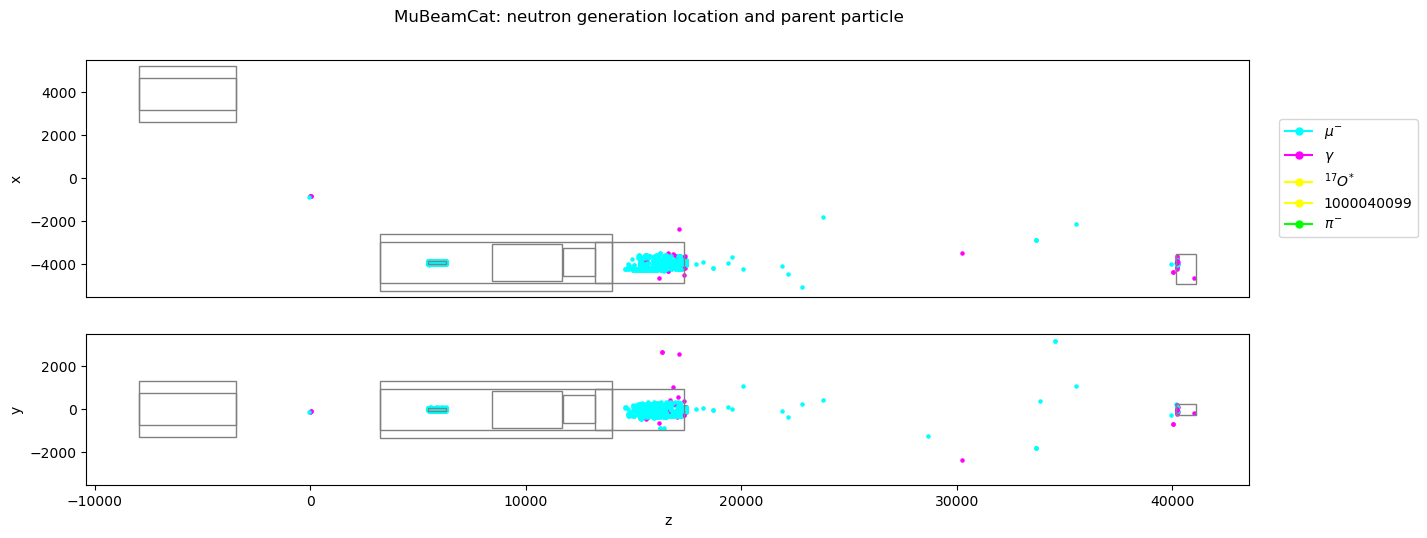

In [7]:
dfs_Mu, fig, ax_top, ax_side = plot_utils.draw_neutron_source_all(dfn_Mu, dfg_Mu, "MuBeamCat: neutron generation location and parent particle")

In [8]:
print ("Total of %i neutrons from MuBeamCat"%len(dfs_Mu))
print ("    %5i with photons as parent"%len(dfs_Mu.query("parentId==22").reset_index(drop=True)))
print ("    %5i with muons   as parent"%len(dfs_Mu.query("parentId==13").reset_index(drop=True)))

Total of 4350 neutrons from MuBeamCat
       96 with photons as parent
     4249 with muons   as parent


Text(0.5, 1.0, 'Neutron creation time and location (muon parent)')

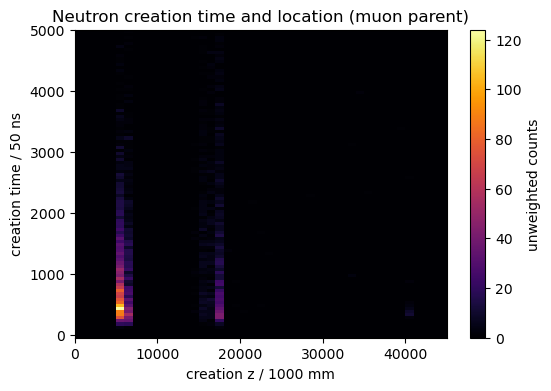

In [9]:
xbins = np.linspace(0., 45000., 46)
ybins = np.linspace(-50., 5000., 102)
fig,ax1 = plt.subplots(figsize=(6, 4))
dfs_Mu13 = dfs_Mu.query("parentId==13").reset_index(drop=True)
H1, xe1, ye1 = np.histogram2d(
    dfs_Mu13['z'], dfs_Mu13['starttime'],
    bins=[xbins, ybins]
)
mesh1 = ax1.pcolormesh(xbins, ybins, H1.T, cmap="inferno")
fig.colorbar(mesh1, ax=ax1, label="unweighted counts", location="right", pad=0.05, orientation='vertical')
ax1.set_xlabel('creation z / 1000 mm')
ax1.set_ylabel('creation time / 50 ns')
ax1.set_title('Neutron creation time and location (muon parent)')

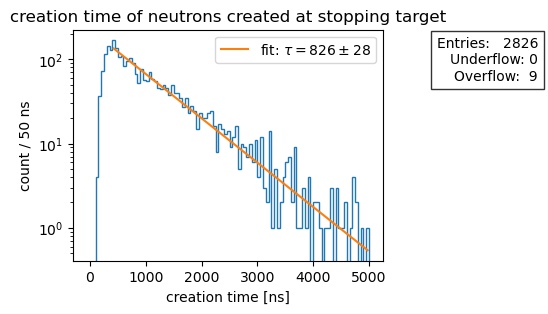

In [10]:
from scipy.optimize import curve_fit

def expo(x, A, tau):
    return A * np.exp(-x / tau)

fig, ax = plt.subplots(figsize=(4,3))
mydf = dfs_Mu13.query("z<10000 and z>1000").reset_index(drop=True)
counts, bin_edges, _ = ax.hist(mydf['starttime'], ybins, histtype='step')

bin_centers = bin_edges[1:]-0.5*(bin_edges[1]-bin_edges[0])
p0=(500., 700.)
popt, pcov = curve_fit(expo, bin_centers[9:], counts[9:], p0=p0)
A, tau = popt
Aerr, tauerr = np.sqrt(np.diag(pcov))
xfit = np.linspace(bin_centers[9], bin_centers.max(), 300)
ax.plot(xfit, expo(xfit, *popt), '-', label=fr'fit: $\tau={tau:.0f}\pm{tauerr:.0f}$')

ax.set_title('creation time of neutrons created at stopping target')
ax.set_xlabel('creation time [ns]')
ax.set_ylabel('count / 50 ns')
entries = len(mydf['starttime'])
mean = np.mean(mydf['starttime'])
std = np.std(mydf['starttime'])
underflow = (mydf['starttime'] < 0.).sum()
overflow  = (mydf['starttime'] > 5000.).sum()
textstr = (
    f"Entries:   {entries}\n"
    #f"Mean:      {mean:.3f}\n"
    #f"Std Dev:   {std:.3f}\n"
    f"Underflow: {underflow}\n"
    f"Overflow:  {overflow}"
)
ax.text(
    1.5, 0.97, textstr,
    transform=ax.transAxes,
    fontsize=10,
    va='top', ha='right',
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
)
ax.set_yscale('log')
ax.legend()

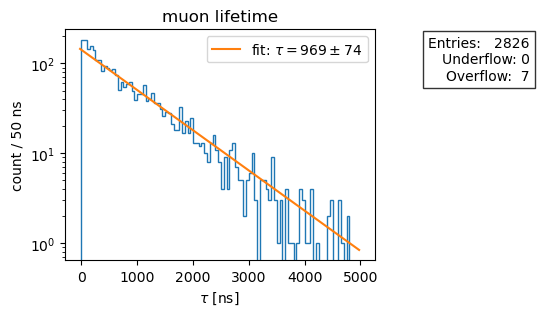

In [11]:
fig, ax = plt.subplots(figsize=(4,3))
mydf = dfs_Mu13.query("z<10000 and z>1000").reset_index(drop=True)
counts, bin_edges, _ = ax.hist(mydf['starttime']-mydf['parentendtime'], ybins, histtype='step')

bin_centers = bin_edges[1:]-0.5*(bin_edges[1]-bin_edges[0])
p0=(500., 700.)
popt, pcov = curve_fit(expo, bin_centers[:], counts[:], p0=p0)
A, tau = popt
Aerr, tauerr = np.sqrt(np.diag(pcov))
xfit = np.linspace(bin_centers[0], bin_centers.max(), 300)
ax.plot(xfit, expo(xfit, *popt), '-', label=fr'fit: $\tau={tau:.0f}\pm{tauerr:.0f}$')

ax.set_title('muon lifetime')
ax.set_xlabel(r'$\tau$ [ns]')
ax.set_ylabel('count / 50 ns')
entries = len(mydf['starttime']-mydf['parentendtime'])
mean = np.mean(mydf['starttime']-mydf['parentendtime'])
std = np.std(mydf['starttime']-mydf['parentendtime'])
underflow = (mydf['starttime']-mydf['parentendtime'] < 0.).sum()
overflow  = (mydf['starttime']-mydf['parentendtime'] > 5000.).sum()
textstr = (
    f"Entries:   {entries}\n"
    #f"Mean:      {mean:.3f}\n"
    #f"Std Dev:   {std:.3f}\n"
    f"Underflow: {underflow}\n"
    f"Overflow:  {overflow}"
)
ax.text(
    1.5, 0.97, textstr,
    transform=ax.transAxes,
    fontsize=10,
    va='top', ha='right',
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
)
ax.set_yscale('log')
ax.legend()

In [12]:
print("Neutrons from muons at target")
creationCode_list = np.sort(mydf['creationCode'].unique())
print("creation code", creationCode_list)
for i, v in enumerate(creationCode_list):
    print("Code ",v, " count: ", len(mydf.query("creationCode==@v").reset_index(drop=True)))

Neutrons from muons at target
creation code [115]
Code  115  count:  2826


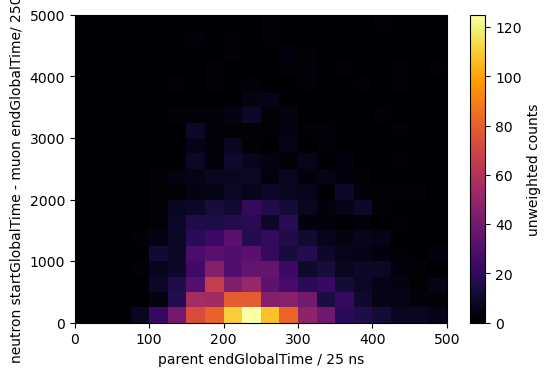

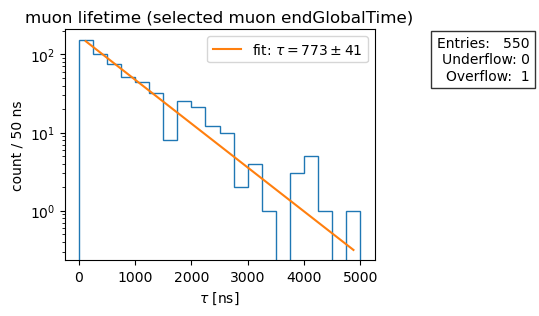

In [13]:
xbins = np.linspace(0., 500., 21)
ybins = np.linspace(0., 5000., 21)
fig,ax1 = plt.subplots(figsize=(6, 4))
H1, xe1, ye1 = np.histogram2d(
    mydf['parentendtime'], mydf['starttime']-mydf['parentendtime'],
    bins=[xbins, ybins]
)
mesh1 = ax1.pcolormesh(xbins, ybins, H1.T, cmap="inferno")
fig.colorbar(mesh1, ax=ax1, label="unweighted counts", location="right", pad=0.05, orientation='vertical')
ax1.set_xlabel('parent endGlobalTime / 25 ns')
ax1.set_ylabel('neutron startGlobalTime - muon endGlobalTime/ 250 ns')

###

fig, ax = plt.subplots(figsize=(4,3))
df_ = mydf.query("parentendtime<500 and parentendtime>300").reset_index(drop=True)
counts, bin_edges, _ = ax.hist(df_['starttime']-df_['parentendtime'], ybins, histtype='step')

bin_centers = bin_edges[1:]-0.5*(bin_edges[1]-bin_edges[0])
p0=(500., 700.)
popt, pcov = curve_fit(expo, bin_centers[:], counts[:], p0=p0)
A, tau = popt
Aerr, tauerr = np.sqrt(np.diag(pcov))
xfit = np.linspace(bin_centers[0], bin_centers.max(), 300)
ax.plot(xfit, expo(xfit, *popt), '-', label=fr'fit: $\tau={tau:.0f}\pm{tauerr:.0f}$')

ax.set_title('muon lifetime (selected muon endGlobalTime)')
ax.set_xlabel(r'$\tau$ [ns]')
ax.set_ylabel('count / 50 ns')
entries = len(df_['starttime'])
mean = np.mean(df_['starttime']-df_['parentendtime'])
std = np.std(df_['starttime']-df_['parentendtime'])
underflow = (df_['starttime']-df_['parentendtime'] < 0.).sum()
overflow  = (df_['starttime']-df_['parentendtime'] > 5000.).sum()
textstr = (
    f"Entries:   {entries}\n"
    #f"Mean:      {mean:.3f}\n"
    #f"Std Dev:   {std:.3f}\n"
    f"Underflow: {underflow}\n"
    f"Overflow:  {overflow}"
)
ax.text(
    1.5, 0.97, textstr,
    transform=ax.transAxes,
    fontsize=10,
    va='top', ha='right',
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
)
ax.set_yscale('log')
ax.legend()